# Trilha da Acadêmica: Uma introdução às Redes Neurais Generativas Adversariais (GANs)

**Nome:** Mariana Melo Pereira

## Proposta do material

No contexto da nossa formação em Ciência e Tecnologia, nós, estudantes da Ilum, somos frequentemente apresentados a modelos computacionais voltados para análise, previsão e classificação de dados, não é mesmo? Desde as disciplinas de Probabilidade e Estatística e Aprendizado de Máquina, exploramos modelos e estratégias que nos permitem aprender sobre determinado conjunto de dados e generalizar as regras inferidas. Agora, na disciplina de Redes Neurais e Algoritmos Genéticos, estamos conhecendo novos modelos, que conseguem captar relações não lineares nos dados de treino, e, além disso, são capazes de lidar com dados não tabulados, indo desde imagens até áudios.

Nesse contexto, surge a ideia principal deste notebook: explorar uma abordagem complementar, a dos modelos generativos, cujo objetivo não é apenas analisar dados existentes, mas criar novos dados com características semelhantes às observadas no mundo real. As Redes Neurais Generativas Adversariais (GANs) são um dos principais exemplos dessa abordagem e têm grande relevância em áreas como visão computacional e ciência de dados, sendo elas, segundo o Mestre C4SS4R, "as avós dos modelos generativos atuais (como o ChatGPT, Gemini, DeepSeek, Nano Banana, etc) e um excelente início na nossa jornada de aprender como redes neurais podem ser utilizadas para criar coisas". 

Apesar de sua relevância, elas costumam ser tratadas de forma excessivamente técnica. Este material propõe uma introdução conceitual, intuitiva e prática ao tema, assumindo nenhum contato prévio com GANs. Por meio de explicações acessíveis, metáforas e um exemplo computacional simples e replicável, o objetivo é permitir que qualquer um de nós compreenda o funcionamento, as limitações e o potencial das GANs, desenvolvendo autonomia para explorar modelos generativos mais complexos em estudos futuros.

## Público-alvo

Este material é direcionado aos estudantes de graduação em Ciência, Tecnologia ou áreas afins que não possuem contato prévio com Redes Neurais Generativas (GANs). Assume-se familiaridade básica com programação e noções gerais de aprendizado de máquina, mas nenhuma experiência anterior com modelos generativos.

## Objetivos de aprendizado
- Entender o que significa gerar dados
- Compreender a lógica de uma GAN
- Treinar uma GAN simples
- Interpretar resultados bons e ruins (a partir das curvas de loss e da análise visual dos resultados)
- Conhecer tipos de GANs e suas aplicações

## 1. Introdução e Motivação: por que GANs existem?

Ao longo do desenvolvimento do aprendizado de máquina, a maior parte dos modelos foi projetada para analisar dados existentes, realizando tarefas como classificação (decidir a qual categoria um dado pertence) ou regressão (estimar valores de um *target* a partir de padrões observados). Nesses casos, o objetivo do modelo é responder corretamente a uma pergunta bem definida como "qual é esse dígito?", identificar um objeto em uma imagem ou prever um valor numérico, como a massa de um pinguim ou a temperatura de ebulição de determinado material.

Já as Redes Neurais Generativas Adversariais (GANs) surgem a partir de uma pergunta diferente: é possível treinar uma máquina para criar novos dados, e não apenas classificá-los ou prevê-los? Basicamente, em vez de responder "o que é isso?", uma GAN aprende a responder "isso parece real?" e, a partir disso, produz exemplos inéditos que seguem as mesmas características dos dados observados. Essa transição, do reconhecimento para a geração, representa uma mudança conceitual importante no papel dos modelos computacionais.

Nesse sentido, as GANs se destacam como uma das abordagens mais influentes da modelagem generativa. Elas são compostas por duas redes neurais treinadas simultaneamente em um processo competitivo: o gerador, que tenta criar dados cada vez mais realistas a partir de ruído aleatório, e o discriminador, que tenta distinguir dados reais de dados gerados. Essa dinâmica adversarial faz com que ambas as redes se aprimorem continuamente, resultando em um sistema capaz de reproduzir distribuições complexas de dados, e será melhor explorada na seção "Apresentando as regras do jogo (e dos adversários)".

Os resultados desse processo podem ser frequentemente apresentados de forma visual e intuitiva, como rostos humanos sintéticos que não correspondem a pessoas reais, ou dígitos manuscritos falsos que se assemelham aos do conjunto MNIST, que é o caso explorado nesse notebook. Esses exemplos ajudam a evidenciar o que torna as GANs especiais: não se trata de reconhecer imagens existentes, mas de inventar novas imagens plausíveis, convincentes e estatisticamente semelhantes às reais.

O objetivo deste trabalho, então, é que nós construamos juntos uma compreensão sólida sobre o que significa ensinar uma máquina a criar dados, explorando tanto o potencial criativo das GANs quanto seus desafios e limitações. Ao longo do notebook, seremos guiados por explicações conceituais, visualizações e exemplos replicáveis, culminando no treinamento de uma GAN utilizando a biblioteca PyTorch.

Dessa forma, depois de toda a contextualização do notebook e nossa motivação para aprender sobre GANs, se for para ressaltar uma mensagem-chave, seria a seguinte:

> "GANs não respondem perguntas... elas inventam respostas plausíveis."

## 2. E então... que tipo de problema uma GAN pode resolver?

As Redes Neurais Generativas Adversariais não foram criadas para resolver os mesmos tipos de problemas que modelos clássicos de aprendizado de máquina, como classificadores ou regressões. Seu foco principal está em modelagem generativa, isto é, em aprender a estrutura de uma distribuição de dados para criar novos exemplos plausíveis, e não para prever rótulos ou valores específicos.

Entender que tipo de problema uma GAN resolve é essencial para saber quando faz sentido utilizá‑la, e quando outras abordagens são mais apropriadas. Entre as suas aplicações, podemos citar [2]:

#### Problemas de geração de dados

O problema central que uma GAN resolve é:

> *Como gerar novos dados que se pareçam com os dados reais disponíveis?*

Isso inclui a criação de imagens sintéticas, sons ou músicas artificiais, textos estilisticamente coerentes e dados tabulares simulados. Nesses casos, a GAN não aprende regras explícitas, mas sim a distribuição dos dados reais, produzindo exemplos que são estatisticamente similares a eles. Por isso, pode-se dizer que uma GAN aprende “como os dados costumam ser”, não “qual é a resposta certa”. E é isso que significa, em sua essência, gerar dados.

#### Problemas onde não há rótulos disponíveis

GANs tmabém são particularmente úteis quando os dados não possuem rótulos, ou então quando a rotulação é cara, subjetiva ou inviável, sendo o interesse na estrutura dos dados, não nas categorias. Como o treinamento adversarial não exige rótulos semânticos, as GANs se enquadram em um contexto não supervisionado ou auto‑supervisionado. Como exemplo, pense em situações que oferecem bases grandes de imagens sem anotação, como dados médicos anonimizados e registros experimentais complexos.

#### Aumento e síntese de dados

Outro tipo importante de problema resolvido por GANs é a geração de dados sintéticos para complementar bases reais. Isso é útil quando o conjunto de dados é pequeno, há desbalanceamento entre classes ou se os dados reais são sensíveis ou confidenciais. Embora o modelo final não seja uma GAN, ela pode ser usada como ferramenta auxiliar para melhorar o treinamento de outros algoritmos.

#### Simulação e criação de cenários plausíveis

GANs podem ser usadas para simular cenários realistas, desde que os dados reais de treinamento capturem corretamente o fenômeno de interesse. Como exemplos, temos a simulação de imagens experimentais, a geração de padrões físicos ou biológicos e a criação de amostras plausíveis para testes de sistemas. Nesse contexto, o objetivo não é recriar um dado específico, mas gerar exemplos consistentes com o comportamento observado.

#### Problemas criativos e exploratórios

Um aspecto distintivo das GANs é seu potencial em tarefas criativas, onde não existe uma única resposta correta. Exemplos incluem  geração artística, com a estilização de imagens, exploração de variações visuais ou sonoras ou até mesmo prototipagem rápida de ideias. Nesses casos, a subjetividade do resultado não é um problema, mas parte do objetivo.

---

Em suma, as GANs não envolvem a pergunta: “Uma GAN resolve este problema?”. Na verdade, é mais produtivo perguntar: “Este problema exige gerar novos dados plausíveis, ou apenas analisar dados existentes?”. Se a resposta envolver criação, simulação ou geração, então uma GAN pode ser uma ferramenta adequada.

<div style="
  background-color:#e8f2ff; border-left:5px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Resumo</strong><br>
GANs resolvem problemas de geração de dados, aprendizado de distribuições e criação de exemplos plausíveis, especialmente quando não há rótulos ou respostas corretas bem definidas. Elas não substituem modelos supervisionados tradicionais, mas atendem a uma classe distinta de problemas.
</div>

Os problemas já sabemos... mas e agora? Como as GANs são capazes de resolvê-los? Para entender isso, temos que saber as regras do jogo intrínseco à existência delas.

## 3. Apresentando as regras do jogo (e dos adversários)

Antes de qualquer implementação ou código, é importante compreender a ideia fundamental por trás das Redes Neurais Generativas Adversariais (GANs). Esse conceito foi introduzido em 2014 por Ian Goodfellow e colaboradores da Universidade de Montreal, incluindo Yoshua Bengio, no artigo "Generative Adversarial Nets" [5]. A proposta foi tão inovadora que o treinamento adversarial foi descrito por Yann LeCun como "uma das ideias mais interessantes dos últimos 10 anos em Machine Learning" [3].

<div style="background-color:#e8f2ff; border-left:5px solid #1f77b4;padding:10px;margin:10px 0; border-radius:6px;">
    <strong>Nesse sentido, temos que...</strong><br>
As GANs surgem como uma nova forma de treinar modelos: não aprendendo sozinhos, mas competindo entre si.
</div>

A essência das GANs pode ser compreendida de forma simples: elas são baseadas em um jogo entre dois adversários, cada um com um objetivo diferente, que aprendem justamente por estarem competindo entre si [1, 4].

O Gerador (dito "o Falsificador") é uma rede neural cujo papel é criar novos dados. Ele começa sem saber absolutamente nada sobre o conjunto de dados reais e recebe como entrada apenas ruído aleatório. A partir desse ruído, o gerador tenta produzir exemplos que se pareçam com os dados do mundo real, como imagens, sons ou textos. Numa metáfora, o gerador funciona como um falsificador de obras de arte: sua missão é criar falsificações cada vez mais convincentes, mesmo sem acesso direto às obras originais.

Já o Discriminador (dito "o Perito") é a rede responsável por avaliar os dados. Ele recebe exemplos reais do conjunto de treinamento e exemplos falsos produzidos pelo gerador, e deve decidir se cada entrada é real ou falsa. Na metáfora, o discriminador é um perito especialista, treinado para identificar se uma obra é autêntica ou uma falsificação. Quanto melhor ele se torna, mais difícil fica para o gerador enganá-lo.


<div style="background-color:#e8f2ff; border-left:5px solid #1f77b4;padding:10px;margin:10px 0; border-radius:6px;">
    <strong> Resumo: Gerador x Discriminador</strong><br>
Gerador: cria dados partindo do ruído e aprende tentando enganar. <br>
Discriminador: avalia dados, decide se é real ou falso e aprende observando exemplos reais e gerados.<br>
</div>

### Mas, afinal... o que cada rede quer ganhar?

O jogo é definido por objetivos opostos:

*   O discriminador quer classificar corretamente todas as amostras como reais ou falsas.
*   O gerador quer produzir dados tão realistas que o discriminador não consiga diferenciá-los dos dados reais.

Eis o motivo pelo qual as GANs, além de generativas, são adversariais... porque o sucesso de um jogador significa o fracasso temporário do outro! Essa oposição é, então, o motivo pelo qual a arquitetura é chamada de adversarial: as duas redes não cooperam diretamente; na verdade, competem em um mesmo ambiente.

### E por que as duas melhoram juntas?

À medida que o "jogo" avança, o discriminador se torna mais criterioso e aprende padrões cada vez mais sutis dos dados reais. Em resposta, o gerador precisa criar exemplos cada vez melhores para conseguir enganá-lo. Esse ciclo leva a um aperfeiçoamento contínuo de ambos os jogadores e o processo continua até que o discriminador tenha grande dificuldade em distinguir dados reais de dados gerados. Quando isso acontece, dizemos que o sistema atingiu um certo equilíbrio; ou seja, os dados artificiais se tornaram suficientemente realistas.

É esse mecanismo simples, porém poderoso, que permite às GANs gerar imagens sintéticas, como rostos humanos inexistentes, dígitos manuscritos falsos, músicas ou outros tipos de dados que seguem a mesma distribuição dos dados reais de treinamento. Lembre-se: uma GAN não aprende sozinha; ela aprende jogando.

Essa estratégia adversarial usada em GANs é inovadora e transformou a modelagem generativa, facilitando o desenvolvimento de modelos e algoritmos capazes de criar dados de alta qualidade e realistas. Ela ajudou a resolver desafios de complexidade de cálculos em modelos de deep learning em tarefas como classificação de imagens e reconhecimento de fala, gerar novos dados, incluindo imagens ou texto realistas. 

Nos próximos passos, veremos quais são os ingredientes necessários para que esse jogo aconteça na prática. Mas, sabe uma coisa que eu estava pensando? O que GANs não fazem?

## 4. O que GANs NÃO fazem?

Antes de avançar para a implementação e os detalhes do treinamento, é importante esclarecer alguns equívocos comuns. Como GANs utilizam redes neurais, é natural confundi-las com outros modelos de aprendizado de máquina mais tradicionais. No entanto, as GANs possuem objetivos e mecanismos bastante diferentes. Nesse sentido, entender o que GANs <em>não são</em> é tão importante quanto entender como elas funcionam... então, vamos lá?

### GANs não são classificadores

Como já sabemos da disciplina de Aprendizado de Máquina, modelos de classificação aprendem a associar uma entrada a uma categoria específica. Por exemplo, podemos identificar se uma imagem contém um gato ou um cachorro. O objetivo é produzir a resposta correta dentro de um conjunto fixo de opções. Porém, GANs não fazem isso. Embora o discriminador produza uma saída parecida com uma classificação (real ou falso), essa decisão não é o objetivo final do modelo, mas apenas parte de um jogo interno que guia o aprendizado do gerador.

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Então, fique com a seguinte intuição:</strong> O discriminador não existe para classificar imagens do mundo real, mas para desafiar o gerador a melhorar.
</div>

### GANs não usam rótulos

Em modelos supervisionados, como também já vimos em Aprendizado de Máquina, cada dado de treinamento vem acompanhado de um rótulo externo (por exemplo, "este dígito é um 7"). GANs, por outro lado, não dependem desse tipo de informação. No caso, o discriminador recebe apenas dois tipos de exemplos:

*   dados reais, vindos do conjunto de treinamento;
*   dados falsos, criados pelo gerador.

Ele não aprende categorias semânticas, apenas tenta identificar a origem do dado.

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>A ideia é...</strong> GANs aprendem a partir de dados reais e gerados, não de rótulos explícitos.
</div>

### GANs não aprendem “a resposta correta”

Em muitos algoritmos de aprendizado de máquina, existe uma noção clara de erro: cada previsão pode ser comparada a uma resposta correta conhecida. Já nas GANs, essa referência fixa não existe; o gerador nunca recebe uma resposta dizendo "isso está certo" ou "isso está errado". Ele aprende apenas observando se conseguiu ou não enganar o discriminador naquele momento do jogo.

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Ideia‑chave:</strong> Em GANs, aprender não significa acertar uma resposta, mas produzir algo cada vez mais plausível.
</div>

### Um resuminho para sintetizar as informações e "gerar" novos conhecimentos...

Como é comum confundir o real objetivo das redes generativas, vamos montar uma tabelinha para mostrar a diferença entre classificação supervisionada e as GANs, dado o que acabamos de discutir.

| Aspecto                        | Classificação Supervisionada                   | GAN (Generative Adversarial Network)                  |
| ------------------------------ | ---------------------------------------------- | ----------------------------------------------------- |
| Objetivo principal             | Prever a resposta correta para uma entrada     | Gerar novos dados semelhantes aos reais               |
| Tipo de saída                  | Uma classe ou rótulo (ex.: gato, cachorro)     | Um novo dado (ex.: imagem, som, texto)                |
| Uso de rótulos                 | Utiliza rótulos explícitos                     | Não utiliza rótulos explícitos                        |
| Papel dos dados reais          | Servem como referência direta para o erro      | Definem a distribuição a ser imitada                  |
| Noção de erro                  | Diferença entre previsão e resposta correta    | Sucesso ou fracasso em enganar o discriminador        |
| Estrutura do modelo            | Um único modelo                                | Dois modelos em competição (Gerador × Discriminador)  |
| Tipo de aprendizado            | Supervisionado                                 | Não supervisionado / adversarial                      |
| Pergunta que o modelo responde | "Qual é a resposta certa?"                     | "Isso parece real?"                                   |
| Exemplos típicos               | Classificação de imagens, diagnóstico    | Geração de imagens, rostos sintéticos, dígitos falsos |

E é justamente essas diferenças conceituais que nos permitem adiantar a resposta para uma pergunta muito importante:

### Por que não dividimos os dados em treino e teste neste contexto?
Em tarefas de aprendizado supervisionado, a separação entre conjuntos de treino e teste é fundamental porque o objetivo do modelo é prever a resposta correta para entradas nunca vistas. Nesse caso, os dados de teste dão a capacidade de generalização do modelo, permitindo avaliar quão bem ele aprendeu uma função que mapeia entradas para rótulos corretos. A noção de erro está explicitamente definida como a diferença entre a previsão do modelo e a resposta correta, o que torna essencial avaliar o desempenho fora do conjunto de treinamento.

No caso das GANs, o objetivo do aprendizado é conceitualmente distinto, como acabamos de discutir. A GAN não busca prever rótulos nem responder a perguntas do tipo “qual é a resposta certa?”, mas sim aprender a distribuição dos dados reais para gerar novas amostras plausíveis. Os dados reais não são utilizados como alvos individuais a serem previstos, mas como referência global da distribuição que o Gerador tenta imitar e que o Discriminador tenta reconhecer. Dessa forma, não há uma noção direta de generalização baseada em exemplos individuais, nem uma métrica de erro que compare saída e rótulo verdadeiro.

Além disso, como o treinamento de uma GAN é adversarial e não supervisionado, utilizar todo o conjunto disponível de dados reais é desejável, pois cada amostra contribui para definir melhor a distribuição que se deseja modelar. Especialmente em contextos didáticos e exploratórios, a avaliação do modelo é predominantemente qualitativa (por inspeção visual das amostras geradas) e baseada no equilíbrio entre Gerador e Discriminador, com as curvas de loss, e não em métricas calculadas sobre um conjunto de teste separado.

Fica então, desde já, esclarecido o porquê de não separarmos nossos dados em treino e teste!

---

Agora sim! Vamos entender melhor sobre as dinâmica de treinamento das nossas queridas redes?

## 5. À geração e além: qual a dinâmica de treinamento por trás das GANs?

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Objetivo da seção</strong><br>
    Entender como o Gerador e o Discriminador aprendem juntos ao longo do treinamento de uma GAN.
</div>

Até aqui, entendemos as GANs como um jogo entre dois adversários e que elas não seguem exatamente as ideias do aprendizado supervisionado, com o qual estamos acostumados a lidar. Agora, vamos observar como esse jogo acontece na prática durante o treinamento, ainda sem recorrer a equações [9, 10].

### O ponto de partida: ruído e dados reais

O processo de treinamento de uma GAN começa com dois tipos de dados disponíveis [5, 7]:

*   Dados reais, vindos diretamente do conjunto de treinamento (por exemplo, imagens reais);
*   Ruído aleatório, normalmente amostras de uma distribuição simples, como uma distribuição normal.

O gerador recebe apenas o ruído aleatório e tenta transformá-lo em dados sintéticos que se pareçam com os dados reais. Ele não sabe o que é um dado "correto".... sua única referência será o feedback do discriminador. Por isso, o gerador começa criando dados completamente sem sentido. Tudo o que ele aprende vem das tentativas de enganar o discriminador, conforme veremos a seguir.

### O papel do discriminador

O discriminador atua como um avaliador. Durante o treinamento, ele recebe exemplos reais do conjunto de dados e exemplos falsos produzidos pelo gerador. Para cada entrada, o discriminador retorna um valor entre 0 e 1, indicando o quão provável é que aquele dado seja real. Valores próximos de 1 indicam dados que parecem autênticos, enquanto valores próximos de 0 indicam dados claramente falsos.

### O ciclo do treinamento adversarial

O treinamento de uma GAN ocorre em um ciclo repetitivo, composto por dois passos principais:

1.  Treinamento do discriminador: O discriminador aprende a distinguir dados reais de dados gerados, ajustando seus parâmetros para melhorar essa separação.

2.  Treinamento do gerador: O gerador é atualizado com base no feedback do discriminador, ajustando seus parâmetros para produzir dados que tenham maior chance de serem considerados reais.

Esse processo de ajuste dos parâmetros acontece por meio da retropropagação do erro, mecanismo padrão no treinamento de redes neurais, mas é aplicado separadamente a cada rede.

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
O gerador nunca vê os dados reais diretamente; ele aprende apenas observando como o discriminador reage às suas criações.
</div>

### Nessa dinâmica, o que significam as perdas?

Durante o treinamento, cada rede possui sua própria função de perda! Isso é muito importante de destacar, pois não é algo que vemos quando estamos aprendendo sobre redes neurais artificiais simples (ANNs). São as funções de perda que indicam quão bem elas estão desempenhando seu papel no jogo, sendo que a perda do discriminador mede o quão bem ele consegue identificar corretamente dados reais e falsos; e a perda do gerador mede o quão bem ele consegue enganar o discriminador.

Uma diminuição na perda do gerador indica que os dados sintéticos estão se tornando mais realistas. Já uma diminuição na perda do discriminador indica que ele está conseguindo identificar corretamente as amostras.

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Atenção!</strong> Em GANs, perdas baixas para ambos os modelos ao mesmo tempo nem sempre indicam um bom treinamento; isso pode ser sinal de desequilíbrio no jogo.
</div>

### Um exemplo concreto: imagens de paçocas

Considere uma GAN treinada para gerar imagens de paçocas. O gerador transforma ruído aleatório em imagens que tentam se parecer com paçocas, enquanto o discriminador avalia essas imagens comparando-as com fotos reais do conjunto de treinamento. Ao longo do tempo, o gerador aprende padrões visuais mais complexos, enquanto o discriminador se torna mais sensível a detalhes sutis.

Então, resumidamente... O treinamento de uma GAN é um processo adversarial no qual o gerador e o discriminador melhoram juntos por meio de um ciclo de competição, guiado por funções de perda e retropropagação.

### Visualizando um esquema da estrutura de uma GAN

<div align="center">
  <img src="https://assets.ibm.com/is/image/ibm/the-structure-of-a-gan?fmt=png-alpha&dpr=on,1.5&wid=960&hei=328" width=1200><br>
  <em>Figura 1: Estrutura de uma GAN. Fonte: IBM [7]</em>
</div><br>

Com o tempo, o processo adversário ilustrado na Figura 1 impulsiona a melhoria de ambas as redes. Isso permite que o gerador crie dados convincentes e realistas que se assemelham ao conjunto de dados de treinamento original, enquanto o discriminador aprimora sua capacidade de identificar diferenças sutis entre dados reais e falsos. 

---

Tendo entendido os conceitos e o fluxo envolvido no treinamento das redes neurais generativas adversariais, podemos partir para a parte "mão na massa"! Por isso, pergunto a vocês:

## 6. 🧑🏼‍💻 Vamos para o Código Mágico?

O Código Mágico, capaz de resolver o desafio proposto, será construído a partir da linguagem Python, em conjunto com as suas bibliotecas torch e matplotlib. O primeiro passo será, então, importar essas bibliotecas para o nosso ambiente de programação.

### Importação das bibliotecas

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

Com as bibliotecas importadas, é interessante que elas não passem desapercebidas pelo leitor não atento... então, vamos chamar a atenção para cada uma delas, indicando suas funcionalidades e importância para cumprir os desafios da melhor maneira possível. Vamos lá?

### Biblioteca de Deep Learning (PyTorch): `torch`

A biblioteca PyTorch (antes chamada somente de torch) é a base para a implementação de redes neurais neste trabalho. Ela fornece estruturas de dados eficientes (os famosos *tensores*), suporte nativo a operações diferenciáveis, execução em CPU ou GPU, e cálculo automático de gradientes (*autograd*, para o algoritmo do *backpropagation*). Essencialmente, é utilizada para construir, treinar e avaliar redes neurais de forma flexível e eficiente.

O seu módulo `torch.nn` contém as principais abstrações para construção de modelos neurais, como as camadas densas (`Linear`), as funções de ativação e as estruturas modulares de rede. Usá‑lo permite definir arquiteturas de diferentes tipos de redes neurais de maneira clara e reutilizável.

Já o módulo `torch.optim` reúne algoritmos de otimização responsáveis por atualizar os pesos da rede durante o treinamento, como o SGD e o Adam. O módulo `torchvision.datasets`, por sua vez, permite acessar conjuntos de dados clássicos, como o MNIST, de forma padronizada; enquanto o `torchvision.transforms` é responsável pelo pré‑processamento das imagens, garantindo que os dados reais estejam no formato e na escala adequados ao modelo. 

Por fim, o `DataLoader`, do módulo `torch.utils.data`, organiza o fornecimento dos dados ao modelo durante o treinamento, dividindo o dataset em mini‑batches e controlando a forma como a distribuição real é apresentada iterativamente às redes. Em modelos generativos adversariais, essas bibliotecas e o pipeline construído a partir delas não apenas suporta o treinamento, mas define diretamente a distribuição que o Gerador tenta aprender e que o Discriminador avalia.

### Biblioteca para visualização de dados: `matplotlib`

A biblioteca Matplotlib, uma velha conhecida nossa, será usada para visualização de curvas de treinamento, com a comparação e análise gráfica da convergência. Ela também auxiliará na interpretação visual dos resultados obtidos a partir dos modelos testados.

---
Tendo entendido as bibliotecas importadas e suas respectivas funcionalidades, bora verificar um detalhezinho muito importante antes de qualquer instanciação ou treino de rede neural; no caso, onde o modelo e os dados irão rodar?

Em PyTorch, é essencial especificar explicitamente o dispositivo de computação (chamado de *device*) que será utilizado, pois a biblioteca permite executar os cálculos tanto na CPU quanto na GPU, quando disponível.

In [2]:
# Definindo o dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

Essa linha realiza uma verificação simples, porém crucial. A função `torch.cuda.is_available()` checa se há uma GPU compatível com CUDA acessível no ambiente de execução. Caso exista, o dispositivo é definido como `"cuda"`, permitindo que o treinamento da rede neural utilize processamento gráfico. Caso contrário, o código automaticamente recorre à `"cpu"`, garantindo que o restante do pipeline funcione corretamente independentemente do hardware disponível.

A principal vantagem dessa abordagem é a portabilidade do código: o mesmo script pode ser executado em diferentes máquinas, desde notebooks pessoais até servidores com GPU, sem necessidade de alterações manuais. Além disso, ao definir o `device` logo no início do programa, torna‑se simples e explícito mover modelos e tensores para o dispositivo correto utilizando o método `.to(device)`, evitando erros comuns relacionados ao uso misto de CPU e GPU.

Portanto, essa etapa, embora simples, é fundamental para assegurar eficiência computacional, reprodutibilidade e robustez do treinamento das redes neurais ao longo de todo o trabalho.

---

Agora sim... com as coisas mais claras e uma explicação aprofundada sobre os detalhes e ferramentas que permeiam a resolução do desafio proposto para os aventureiros da Trilha da Acadêmica, partiremos para a execução do "plano de trabalho". Vamos começar tratando de um problema simples, envolvendo o dataset MNIST, e depois exploramos algumas diferenças que trazem maior complexidade, ok? Então, vamos lá!

## 7. Um exemplo simples para esquentar!

### Transformação para normalizar os dados

O trecho de código abaixo define uma sequência de transformações que será aplicada às imagens antes de elas serem usadas no modelo, utilizando o módulo `transforms` da biblioteca PyTorch. A função `transforms.Compose` serve para encadear várias transformações, garantindo que elas sejam aplicadas sempre na mesma ordem. Nesse caso, duas transformações principais são usadas:

1.  `transforms.ToTensor()`
    Essa transformação converte a imagem (geralmente carregada como um objeto PIL ou um array NumPy) em um tensor do PyTorch. 

2.  `transforms.Normalize((0.5,), (0.5,))`
    Essa etapa realiza a normalização dos dados, ajustando a distribuição dos valores dos pixels. Para cada pixel $x$, a normalização é feita segundo a fórmula:
    $$
    x_{\text{norm}} = \frac{x - 0.5}{0.5}
    $$
    Os parênteses com um único valor indicam que a imagem possui apenas um canal (por exemplo, imagens em tons de cinza).

No conjunto, essas transformações tornam os dados mais adequados para o treinamento de redes neurais, ajudando na estabilidade e eficiência do processo de aprendizado.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Em seguida, precisamos fazer o carregamento do conjunto de dados MNIST e a sua preparação para o treinamento do nosso modelo, sendo este o conjunto de dados escolhido para o exemplo simples que queremos explorar agora de início.

### Carregando o dataset MNIST

Abaixo, a linha que utiliza `datasets.MNIST` cria um objeto contendo os dados de treino do MNIST, que é um conjunto clássico de imagens de dígitos manuscritos (de 0 a 9), como veremos logo depois da célula de código. O parâmetro `root='./data'` indica o diretório onde o dataset será armazenado localmente. Com `train=True`, especifica-se que será usado o conjunto de treinamento, e `download=True` garante que o dataset será baixado automaticamente caso ainda não esteja presente no diretório indicado. O parâmetro `transform=transform` define que cada imagem será processada pelas transformações descritas anteriormente, com a conversão para tensor e a normalização dos valores dos pixels.

Em seguida, o objeto `DataLoader` é utilizado para criar um iterador sobre os dados de treino. O parâmetro `batch_size=64` indica que as imagens serão agrupadas em lotes de 64 amostras, o que torna o treinamento mais eficiente e viável computacionalmente. Já `shuffle=True` garante que os dados sejam embaralhados a cada época, evitando que o modelo aprenda padrões indesejados relacionados à ordem fixa das amostras. Em conjunto, essas instruções organizam os dados de forma eficiente e adequada para o processo de treinamento de redes neurais no PyTorch.

In [4]:
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

### Mas, afinal... o que é esse conjunto de dados simples?

O MNIST (Modified National Institute of Standards and Technology) é um dos conjuntos de dados mais clássicos e utilizados em aprendizado de máquina e visão computacional, especialmente para tarefas introdutórias de classificação de imagens. Ele é composto por 70.000 imagens de dígitos manuscritos, representando os números de 0 a 9. Cada imagem é em tons de cinza, possui resolução de 28 × 28 pixels e mostra apenas um único dígito centralizado. Do total de imagens, 60.000 são destinadas ao conjunto de treinamento e 10.000 ao conjunto de teste, o que permite avaliar o desempenho de modelos de forma padronizada.

<div align="center">
    <img src="https://tse1.mm.bing.net/th/id/OIP.6VP3MnI-0jeSnjhkNHHLygHaDr?rs=1&pid=ImgDetMain&o=7&rm=3"></img>

    Figura 2: Conjunto de dados MNIST. Fonte: https://tse1.mm.bing.net/th/id/OIP.6VP3MnI-0jeSnjhkNHHLygHaDr?rs=1&pid=ImgDetMain&o=7&rm=3
</div><br>


O MNIST surgiu como uma versão simplificada e mais bem organizada de conjuntos de dados anteriores do NIST, facilitando experimentos rápidos e comparáveis entre diferentes métodos. Por conta disso, ele se tornou um benchmark histórico na área, sendo amplamente usado para testar algoritmos como as redes convolucionais (CNNs), que são um outro tipo de modelo de deep learning.

Apesar de hoje ser considerado um dataset relativamente simples para modelos modernos (em problemas de classificação, muitos alcançam acurácias superiores a 99%), o MNIST continua sendo extremamente relevante do ponto de vista didático. Ele é ideal para aprender conceitos fundamentais como pré-processamento de dados, normalização, treinamento em batches, validação, overfitting e avaliação de desempenho. 

Por isso, utilizaremos justamente ele para exemplificar o uso de uma rede do tipo GAN, avaliando o seu funcianamento e desempenho. Bora para o jogo?

### Lembrando um detalhe para o leitor não atento!

Neste experimento, não será realizada a separação entre conjuntos de treino e teste do dataset MNIST. Essa escolha é intencional e está alinhada ao objetivo do uso de Redes Neurais Generativas Adversariais (GANs), cujo foco é aprender a distribuição dos dados reais e não a generalização de rótulos, como ocorre em tarefas de classificação supervisionada. Em contextos didáticos e exploratórios, especialmente quando a avaliação do modelo é predominantemente qualitativa (visual), é prática comum utilizar todo o conjunto disponível de dados reais durante o treinamento. A separação entre treino e teste torna‑se relevante principalmente em avaliações quantitativas rigorosas ou necessidades mais complexas, o que foge ao escopo deste trabalho introdutório.

---
Agora, tendo entendido o contexto do que vamos fazer, podemos partir para a definição das nossas classes e das regras do jogo, em código!

### A definição do primeiro competidor: a rede geradora

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Objetivo da seção</strong><br> Entender como o Gerador atua transformando ruído aleatório em dados sintéticos e qual é seu papel no treinamento adversarial das GANs.
</div>

A seguir, definimos a classe `Generator`, que representa o gerador da GAN que estamos instanciando, implementado-o como uma rede neural totalmente conectada (feedforward) usando o PyTorch. Essa classe herda de `nn.Module`, que é a classe base para todos os modelos de redes neurais na biblioteca.

No método `__init__`, são definidos os parâmetros fundamentais da arquitetura:

*   `input_size`: o tamanho do vetor de entrada, normalmente representando ruído aleatório (noise);
*   `hidden_size`: o número de neurônios nas camadas ocultas;
*   `output_size`: o tamanho do vetor de saída, que geralmente corresponde ao número de pixels da imagem gerada (por exemplo, $28 \times 28 = 784$ no caso do MNIST).

A arquitetura da rede é construída utilizando `nn.Sequential`, que permite empilhar camadas de forma simples e organizada. A primeira camada linear transforma o vetor de entrada no espaço oculto (`input_size → hidden_size`) e é seguida por uma função de ativaçã ReLU, que introduz não linearidade e permite à rede aprender padrões mais complexos. Em seguida, há uma segunda camada linear com o mesmo tamanho oculto, novamente acompanhada de uma ativação ReLU, aprofundando a capacidade de representação do modelo.

A camada final é uma transformação linear que mapeia os neurônios ocultos para o espaço de saída (`hidden_size → output_size`). Após essa camada, é aplicada a função de ativação `Tanh`, que limita os valores da saída ao intervalo $[-1, 1]$. Essa escolha é comum em geradores de GANs quando os dados de saída (como imagens) também foram normalizados para esse intervalo, como foi anteriormente realizado nesse notebook, garantindo compatibilidade entre o gerador e o conjunto de dados real.

O método `forward()` define o fluxo de dados pela rede. Ele recebe um vetor de entrada `x` e o passa por todas as camadas definidas em `self.model`, retornando o vetor de saída, que representa uma imagem sintética gerada pelo modelo.

Em resumo, essa classe implementa um gerador que transforma ruído aleatório em dados artificiais estruturados, tentando aprender progressivamente a produzir imagens cada vez mais semelhantes às do conjunto de dados original durante o treinamento da GAN.

In [5]:
class Generator(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(True),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(True),
            nn.Linear(hidden_size, output_size),
            nn.Tanh()
        )
        
    def forward(self, x):
        return self.model(x)

### O segundo adversário: a rede discriminadora

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Objetivo da seção</strong><br> Compreender como o Discriminador avalia dados reais e gerados e por que sua atuação é essencial para guiar o aprendizado do Gerador.
</div>

O código da célula abaixo define a classe `Discriminator`, que representa o discriminador da nossa GAN. Como já aprendemos, o papel do discriminador é atuar como um classificador binário, aprendendo a distinguir entre dados reais (vindos do conjunto de treinamento) e dados falsos (gerados pelo gerador).

Assim como a anterior, essa classe também herda de `nn.Module`, que é a estrutura base do PyTorch para a definição de modelos de redes neurais. No método `__init__`, são especificados os principais parâmetros da arquitetura:

*   `input_size`, que corresponde ao tamanho da entrada do modelo (por exemplo, o número de pixels de uma imagem achatada, como 784 no caso do MNIST);
*   `hidden_size`, que define o número de neurônios nas camadas ocultas.

A arquitetura do discriminador é então construída utilizando `nn.Sequential`, organizando as camadas de forma linear e intuitiva. A primeira camada `nn.Linear` mapeia a entrada para o espaço oculto (`input_size → hidden_size`) e é seguida pela função de ativação LeakyReLU, com parâmetro $\alpha$ de 0.2 (vamos entender o que é esse $\alpha$ logo mais). Essa função é utilizada no lugar da ReLU tradicional para evitar o problema de neurônios mortos, permitindo que pequenos gradientes continuem fluindo mesmo para valores negativos.

Em seguida, há uma segunda camada linear, que mantém o mesmo tamanho oculto (`hidden_size → hidden_size`), novamente acompanhada por uma ativação LeakyReLU. Essa camada adicional aumenta a capacidade do modelo de aprender características mais complexas dos dados de entrada.

A camada final do discriminador é uma transformação linear que reduz a saída para um único valor (`hidden_size → 1`). Após essa camada, é aplicada a função Sigmoid, que restringe a saída ao intervalo $[0, 1]$. Esse valor pode ser interpretado como a probabilidade de a amostra ser real, sendo valores próximos de 1 associados a dados reais e valores próximos de 0 a dados falsos gerados pelo gerador. O método `forward()`, por sua vez, define o fluxo de dados pela rede, recebendo a entrada `x` e propagando-a por todas as camadas definidas em `self.model`, retornando a previsão final do discriminador.

Em resumo, essa classe implementa um discriminador que aprende, durante o treinamento adversarial, a diferenciar imagens reais de imagens sintéticas, pressionando o gerador a produzir dados cada vez mais realistas ao longo do processo de treinamento da GAN.

In [6]:
class Discriminator(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

### Prestando atenção aos detalhes: as funções ReLU e LeakyReLU

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Objetivo da seção</strong><br> Entender o que são as funções de ativação ReLU e LeakyReLU e por que elas foram as escolhidas.
</div>

A função de ativação é um componente central das redes neurais, pois é ela que introduz não linearidade no modelo, permitindo que a rede aprenda relações complexas entre os dados. Sem funções de ativação não lineares, uma rede profunda seria matematicamente equivalente a um modelo linear, independentemente do número de camadas. Nesse contexto, funções como ReLU e LeakyReLU tornaram‑se escolhas padrão, especialmente em arquiteturas profundas e em modelos generativos.

A função ReLU é definida matematicamente como:

$$
\text{ReLU}(x) = \max(0, x)
$$

Ou seja, a saída da função é igual ao valor de entrada quando ele é positivo, e zero caso contrário. Essa definição simples traz várias vantagens práticas. Em primeiro lugar, a ReLU é computacionalmente eficiente, pois envolve apenas uma comparação e não requer o cálculo de funções mais custosas, como exponenciais. Além disso, ao não saturar para valores positivos, ela reduz significativamente o problema do *vanishing gradient*, comum em funções como a sigmoide ou a tangente hiperbólica.

Outro aspecto importante é o efeito de esparsidade introduzido pela ReLU. Como valores negativos são zerados, muitas ativações tornam‑se exatamente zero, o que pode ajudar o modelo a aprender representações mais compactas e discriminativas. Por essas razões, a ReLU é amplamente utilizada nas camadas internas de redes profundas, onde se deseja favorecer gradientes estáveis e aprendizado eficiente durante a expansão progressiva de uma imagem, como em nosso caso.

No entanto, a ReLU também apresenta uma limitação conhecida como o problema dos neurônios mortos. Se durante o treinamento um neurônio passa a receber apenas entradas negativas, sua saída permanecerá sempre zero, e o gradiente associado a ele também será zero. Isso impede que o neurônio volte a contribuir para o aprendizado, o que pode reduzir a capacidade expressiva da rede.

Assim, surge a função LeakyReLU, como uma modificação simples da ReLU justamente para mitigar o problema dos neurônios mortos. Sua definição é:

$$
\text{LeakyReLU}(x) =
\begin{cases}
x, & x > 0 \\
\alpha x, & x \leq 0
\end{cases}
$$

onde $\alpha$ é uma constante pequena e positiva (em nosso caso, $\alpha = 0{,}2$). Diferentemente da ReLU padrão, a LeakyReLU permite que valores negativos produzam uma saída pequena, mas diferente de zero. Isso garante que o gradiente continue fluindo mesmo quando a ativação é negativa.

Essa característica é particularmente importante no Discriminador das GANs. Como o discriminador precisa ser sensível a uma grande variedade de padrões, tanto de imagens reais quanto de imagens geradas, perder neurônios devido a gradientes nulos pode comprometer sua capacidade de aprendizado. A LeakyReLU mantém o modelo ativo em todas as regiões do espaço de entrada, contribuindo para um treinamento adversarial mais estável.

Além disso, o uso da LeakyReLU ajuda a evitar situações em que o discriminador se torna excessivamente rígido, o que poderia dificultar o aprendizado do gerador. Ao permitir pequenos gradientes mesmo para ativações negativas, o discriminador fornece um sinal de erro mais informativo ao gerador.

---

Que bonito! Com as classes devidamente definidas e as funções de ativação explicadas, podemos partir para a inicialização do processo adversarial do treinamento da nossa GAN. Por isso, começamos definindo alguns parâmetros necessários.

### Definindo alguns parâmetros importantes

Na célula de código abaixo, são declarados os parâmetros requisitados para a concretização deste experimento com GANs. Como primeiro parâmetro, o espaço latente é definido por um vetor de dimensão `latent_size = 100`, que representa a fonte de aleatoriedade utilizada pelo gerador para criar novas amostras. 

> Mais detalhadamente, o espaço latente corresponde ao conjunto de vetores aleatórios a partir dos quais o Gerador constrói novas amostras. Cada vetor no espaço latente atua como uma representação compacta e abstrata das possíveis variações presentes nos dados reais, funcionando como a fonte de aleatoriedade e diversidade do modelo. Como o vetor é compacto, se comparado às dimensões das imagens, é possível capturar variações relevantes dos dados sem tornar o modelo excessivamente complexo. 

Já as camadas internas da rede utilizam `hidden_size = 256` neurônios, fornecendo capacidade suficiente para aprender padrões não lineares tanto no gerador quanto no discriminador. As imagens trabalhadas possuem dimensão `image_size = 28 × 28`, correspondendo a imagens em tons de cinza que são achatadas em vetores para facilitar o processamento pelas redes totalmente conectadas. 

O treinamento é realizado com uma taxa de aprendizado `lr = 0.0002`, um valor comumente adotado em GANs por favorecer um equilíbrio estável entre o gerador e o discriminador durante a otimização. Por fim, define-se que o modelo será treinado ao longo de `num_epochs = 100` épocas, permitindo observar o comportamento da dinâmica adversarial e a qualidade das imagens geradas nas primeiras 100 fases do aprendizado.

In [7]:
latent_size = 100
hidden_size = 256
image_size = 28*28
lr = 0.0002
num_epochs = 100

### Parâmetros e funções para um experimento diferente...

Além do treinamento da rede e da visualização das curvas de loss, vou propor um experimento adicional. Quero visualizar a evolução do gerador e a qualidade das imagens geradas em diferentes épocas. Por isso, defini que quero uma quantidade de `num_examples = 16`. Além disso, a variável `fixed_noise`, que corresponde a um conjunto fixo de vetores do espaço latente, torna possível observar como as mesmas posições no espaço latente evoluem durante o treinamento, já que estamos utilizando sempre o mesmo ruído como entrada do Gerador. 

Esses vetores do espaço latente são gerados aleatoriamente no início do experimento, têm dimensão igual ao tamanho do espaço latente (`latent_size`) e são mantidos constantes ao longo das épocas. Assim, qualquer mudança visual nas imagens geradas reflete exclusivamente o aprendizado do Gerador, e não variações aleatórias na entrada. Esse procedimento é fundamental para comparar de forma consistente o estado inicial, intermediário e final do modelo.

In [8]:
# Número de imagens que queremos visualizar
num_examples = 16

# Ruído fixo para acompanhar a evolução do Gerador
fixed_noise = torch.randn(num_examples, latent_size).to(device)

Para colocar em prática o experimento, criei também a função definida na célula abaixo.

Ao iniciar a função, o comando `G.eval()` coloca o Gerador em modo de avaliação. Isso é importante porque desativa comportamentos específicos do modo de treino e garante que a saída do modelo seja consistente e reprodutível durante a visualização das imagens. Em seguida, o bloco `with torch.no_grad():` indica que nenhuma informação de gradiente deve ser armazenada durante essa etapa. Como o objetivo da função é apenas gerar imagens para inspeção, e não atualizar os parâmetros do modelo, essa instrução reduz o consumo de memória e evita que o grafo computacional cresça desnecessariamente.

Dentro desse contexto, o Gerador recebe o ruído de entrada (noise) e produz imagens sintéticas, armazenadas na variável `fake_images`. Após a geração, o comando `G.train()` devolve o modelo ao modo de treinamento, assegurando que o fluxo normal do aprendizado não seja afetado por essa etapa de visualização. Por fim, a função retorna as imagens geradas.

In [9]:
def gerar_imagens(G, noise):
    G.eval()  # modo avaliação
    with torch.no_grad():
        fake_images = G(noise)
    G.train()  # volta para modo treino
    return fake_images.cpu()

Vamos utilizar essa função mais para frente, durante o treinamento, ok?

Mas está chegando o momento... precisamos, agora, inicializar as redes!

### Últimos minutos antes do jogo... Inicializando as redes

Como já descrito, o nosso modelo será composto por duas redes neurais centrais: o Gerador (G) e o Discriminador (D), instanciadas de forma explícita para refletir seus papéis complementares no treinamento adversarial. 

O gerador é criado na célula seguinte como `G = Generator(latent_size, hidden_size, image_size)`, indicando que ele recebe vetores do espaço latente de dimensão `latent_size`, os transforma por meio de camadas internas com `hidden_size` neurônios e produz imagens sintéticas com dimensão `image_size`. Sua função é aprender a mapear ruído aleatório para amostras que imitem a distribuição dos dados reais. 

Já o discriminador é instanciado como `D = Discriminator(image_size, hidden_size)`, recebendo como entrada imagens (no nosso caso, as do dataset MNIST) de tamanho `image_size` e utilizando camadas ocultas de dimensão `hidden_size` para decidir se uma amostra é autêntica ou falsa. Ambas as redes são transferidas para o dispositivo de execução adequado por meio de `.to(device)`, garantindo que os cálculos sejam realizados de forma eficiente, seja em CPU ou GPU. Juntas, elas estabelecem o jogo adversarial que caracteriza as GANs, no qual o gerador tenta enganar o discriminador enquanto este aprende a se tornar cada vez mais rigoroso em sua classificação.

In [10]:
G = Generator(latent_size, hidden_size, image_size).to(device)
D = Discriminator(image_size, hidden_size).to(device)

Depois de incializar a rede geradora e a discriminadora, vamos para as definições de elementos intrínsecos às redes neurais: a função de perda e os otimizadores.

### Quase que eu ia me esquecendo... escolhendo a função de perda e os otimizadores!

Para o treinamento da GAN, é utilizada como função de perda a Binary Cross-Entropy, definida por `fn_perda = nn.BCELoss()`. Essa escolha é natural no contexto de GANs clássicas, pois o problema enfrentado pelo discriminador é internamente um de classificação binária: distinguir entre imagens reais e imagens geradas pelo gerador. A Binary Cross-Entropy mede o quão distante a probabilidade prevista pelo modelo está do rótulo verdadeiro (real = 1, falso = 0), penalizando fortemente previsões confiantes porém incorretas. Durante o treinamento, o discriminador busca minimizar essa perda ao classificar corretamente amostras reais e falsas, enquanto o gerador utiliza indiretamente a mesma função de perda para ajustar seus parâmetros de modo a produzir imagens que sejam classificadas como reais pelo discriminador.

A otimização dos parâmetros do gerador e do discriminador também é realizada de forma independente, utilizando dois otimizadores distintos baseados no algoritmo Adam, definidos como `optimizer_G = optim.Adam(G.parameters(), lr=lr)` e `optimizer_D = optim.Adam(D.parameters(), lr=lr)`. O uso de otimizadores separados é essencial, pois cada rede possui objetivos opostos e deve ser atualizada de maneira alternada durante o treinamento. O Adam é particularmente adequado para GANs por combinar as vantagens do Momentum e da adaptação individual da taxa de aprendizado para cada parâmetro, o que contribui para maior estabilidade em um cenário de treinamento adversarial, conhecido por ser sensível e, por vezes, instável. A taxa de aprendizado `lr` é mantida igual para ambos os otimizadores, garantindo um ritmo de aprendizado balanceado entre o gerador e o discriminador, evitando que uma das redes domine excessivamente a outra nas fases iniciais do treinamento.

In [11]:
fn_perda = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

### Uma pausa para explicar a BCELoss: quando errar é esperado

Em uma GAN, e mais especificamente em nosso caso, em que temos uma GAN com o objetivo de gerar imagens, a função de perda não mede se os nossos resultados são bonitos, legíveis ou realistas aos olhos humanos. Ela mede algo muito mais específico e mais sutil: probabilidades. A BCELoss, ou *Binary Cross-Entropy Loss*, nasce no contexto da classificação binária e expressa o quão bem um modelo estima a probabilidade de que uma amostra pertença a uma de duas classes possíveis.

No caso das GANs, o Discriminador é treinado como se fosse um classificador binário, pois ele deve atribuir alta probabilidade às imagens reais e baixa probabilidade às imagens geradas. A BCELoss penaliza o modelo sempre que essa confiança probabilística não corresponde ao esperado (ou seja, quando nos "surpreendemos" com a classificação). Se o Discriminador classifica uma imagem falsa como real com alta confiança, sua perda aumenta. Se ele acerta com segurança, a perda diminui.

O papel da BCELoss no Gerador é ainda mais interessante. O Gerador nunca vê imagens reais diretamente, nem recebe um rótulo dizendo “isso é um dígito correto”. Ele aprende indiretamente, tentando produzir imagens que façam o Discriminador errar. Assim, sua loss mede o quanto o Discriminador consegue identificar suas imagens como falsas. Uma loss alta indica que o Gerador ainda produz imagens facilmente rejeitadas; uma loss mais baixa indica que o Discriminador está sendo enganado com mais frequência e, portanto, que o gerador está cumprindo seu paapel.

Essa estrutura explica por que as losses em GANs não se comportam como em modelos tradicionais, e vamos explorar esse detalhe mais adiante.

### Espere mais um pouquinho... vamos entender esse tal de otimizador Adam

Se a BCELoss define o que as redes devem otimizar, o otimizador define como esse aprendizado acontece. Em GANs, essa escolha é especialmente crítica, pois o treinamento é notoriamente instável. Pequenas mudanças nos parâmetros podem levar a oscilações violentas, colapso de modos ou divergência completa.

O otimizador Adam é amplamente adotado em GANs justamente por lidar bem com esse cenário. Ele combina duas ideias importantes: a adaptação da taxa de aprendizado para cada parâmetro individualmente e o uso de médias móveis dos gradientes ao longo do tempo. Isso faz com que atualizações muito errôneas sejam suavizadas, enquanto direções consistentemente úteis sejam reforçadas.

Em termos conceituais, o Adam permite que o Gerador e o Discriminador aprendam em ritmos diferentes, mesmo usando uma taxa de aprendizado global semelhante. Parâmetros que recebem gradientes pequenos, mas consistentes, podem continuar evoluindo; já parâmetros sujeitos a grandes variações têm seus passos automaticamente controlados. Essa adaptatividade é crucial em GANs, onde o “alvo” de cada rede está sempre mudando, pois a outra rede também está aprendendo.

Outro aspecto importante é que o Adam ajuda a manter o treinamento ativo mesmo quando os gradientes se tornam instáveis ou ruidosos, algo extremamente comum quando o Gerador começa a produzir imagens mais realistas e o Discriminador passa a não funcionar tão adequadamente. Em vez de travar o aprendizado, esse otimizador amortiza essas flutuações e permite que o jogo continue.

---

Em conjunto, a BCELoss e o Adam revelam algo fundamental sobre GANs... elas não aprendem buscando uma resposta correta única, mas explorando um território probabilístico em constante mudança. No final das contas, a loss define a regra do jogo e o otimizador define como os jogadores se movem. Entender esses dois elementos é entender por que GANs são, ao mesmo tempo, poderosas, instáveis e fascinantes!

Com as explicações sobre a função de perda e o otimizador devidamente realizadas, e, além disso, com os parâmetros definidos... podemos partir para o treinamento das redes! Mas, peraí... qual a matemática por trás das GANs?

## 8. Matemática: a linguagem universal


<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Objetivo da seção</strong><br> Mostrar como a matemática das GANs formaliza o jogo entre Gerador e Discriminador, conectando a intuição conceitual às equações usadas no treinamento.
</div>

Até aqui, além de introduzirmos as classes que utilizaremos no treino do nosso modelo, descrevemos as Redes Neurais Generativas Adversariais como um jogo entre dois modelos: um que tenta criar dados realistas e outro que tenta distingui-los dos dados reais. Nesta seção, porém, veremos como essa ideia é traduzida para a matemática. Para isso, entendemos que todo o treinamento de uma GAN pode ser compreendido a partir de duas perguntas simples:

1.  O Discriminador consegue dizer se um dado é real ou falso?
2.  O Gerador consegue enganar o Discriminador?

Cada uma dessas perguntas dá origem a uma função de perda. Lembrando: a função de perda, de forma muito simples, é uma medida numérica que informa quão bem cada jogador está desempenhando seu papel no jogo.

Nesse sentido, para representar as nossas duas redes jogadoras, chamaremos:

*   $G$ de Gerador;
*   $D$ de Discriminador.

O gerador recebe um vetor de ruído aleatório $z$, amostrado de uma distribuição simples $p_z(z)$, como uma normal padrão, e produz uma amostra sintética $G(z)$. Já o discriminador recebe uma amostra $x$, que pode ser real ou gerada, e retorna um valor $D(x) \in [0,1]$, interpretado como a probabilidade de $x$ ser um dado real.

O objetivo do Discriminador é, então:

*   atribuir valores altos a dados reais $x \sim p_{data}(x)$;
*   atribuir valores baixos a dados gerados $G(z)$.

Matematicamente, isso é expresso pelo mesmo tipo de função de perda usada em problemas de classificação binária. Seu objetivo é maximizar a expressão [6]:

$$\mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log (1 - D(G(z)))]$$

Traduzindo para palavras, o primeiro termo recompensa o Discriminador por reconhecer corretamente dados reais, enquanto o segundo termo o recompensa por identificar dados falsos como falsos. Intuitivamente, quanto melhor o Discriminador separa dados reais de dados gerados, menor é sua perda e melhor ele está jogando.

O segundo jogador, que chamamos de Gerador, não avalia diretamente seus próprios dados. Ele aprende apenas observando a reação do Discriminador. Seu objetivo é produzir amostras que façam o Discriminador errar.

Na formulação original, o Gerador tenta minimizar [6]:

$$
\mathbb{E}_{z \sim p_z}[\log (1 - D(G(z)))]
$$

Isso significa que ele quer que o valor de $D(G(z))$ seja alto, ou seja, que o Discriminador acredite que os dados gerados são reais. Na prática, essa forma de perda pode causar gradientes fracos no início do treinamento. Por isso, é comum utilizar uma forma alternativa mais estável. Uma versão frequentemente usada na prática consiste, então, em maximizar [6]:

$$
\mathbb{E}_{z \sim p_z}[\log D(G(z))]
$$

Essa formulação tem o mesmo objetivo conceitual: fazer com que o Gerador produza dados cada vez mais convincentes.

#### Um único jogo, dois objetivos opostos

A partir do que vimos até agora, deu para perceber que as duas funções de perda descrevem um único jogo matemático, conhecido como um jogo minimax [5, 6, 11]:

$$\min_G \max_D \; V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log (1 - D(G(z)))]$$

Resumidamente, o Discriminador tenta maximizar essa expressão e o Gerador tenta minimizá‑la.

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Ideia‑chave</strong><br>
A matemática das GANs descreve um jogo de interesses opostos, não a busca por uma resposta correta.
</div>

#### Afinal, o que significa “equilíbrio” em uma GAN?

Em condições ideais, o treinamento atinge um ponto em que o Gerador aprendeu a distribuição dos dados reais, o Discriminador não consegue mais distinguir dados reais de dados gerados e para qualquer entrada, $D(x) \approx 0.5$. Esse ponto corresponde a um equilíbrio do jogo, no qual nenhum dos dois jogadores consegue melhorar sem que o outro também mude sua estratégia [5].

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Resumo</strong><br>
As equações das GANs formalizam um jogo minimax no qual o Discriminador tenta separar dados reais e falsos, enquanto o Gerador tenta tornar essa separação impossível. A intuição pode vir primeiro; a matemática consegue torná-la operacional.
</div>

Matemática explicada, que coisa linda! Agora que entendemos o jogo tanto conceitual quanto matematicamente, podemos analisar como essas equações são implementadas em código, por meio do loop de treinamento. Bora, então, treinar essas redes?

## 9. O árbitro apitou! Que comecem os jogos!

Abaixo, definimos a função `treinar_GAN()` que encapsula todo o processo de treinamento da Rede Gerativa Adversarial ao longo de um número fixo de épocas. Ela recebe como argumentos principais o número de épocas (`num_epochs`), o *dataloader* de treinamento (`train_loader`), o dispositivo de execução (`device`), o tamanho do espaço latente (`latent_size`) e os otimizadores do gerador e do discriminador. Logo no início, são inicializadas duas listas, `valores_d_loss` e `valores_g_loss`, que armazenam a evolução das perdas do discriminador e do gerador ao longo do treinamento, permitindo posteriormente uma análise do comportamento do modelo.

O treinamento ocorre em dois níveis de repetição: um laço externo sobre as épocas e um laço interno que percorre os *mini-batches* fornecidos pelo `train_loader`. Para cada batch, as imagens reais são redimensionadas para vetores unidimensionais e transferidas para o dispositivo de execução. Em seguida, são definidos os rótulos reais (vetores de uns) e falsos (vetores de zeros), que serão usados na função de perda binária.

O primeiro passo em cada iteração é o treinamento do discriminador. Inicialmente, imagens reais são passadas pelo discriminador, e a perda associada (`d_loss_real`) é calculada comparando suas previsões com os rótulos reais. Em seguida, vetores de ruído aleatório `z` são amostrados do espaço latente, e o gerador produz imagens falsas a partir deles. Essas imagens geradas são então avaliadas pelo discriminador, mas com o uso de `.detach()`, garantindo que os gradientes não sejam propagados de volta para o gerador neste estágio. A perda correspondente (`d_loss_fake`) mede a capacidade do discriminador de identificar corretamente imagens falsas. A perda total do discriminador é a soma das perdas com dados reais e falsos, e seus parâmetros são atualizados após a retropropagação.

Na sequência, ocorre o treinamento do gerador. Um novo conjunto de vetores latentes é amostrado, e o gerador produz imagens sintéticas que são avaliadas pelo discriminador. Contudo, neste caso, as imagens geradas recebem rótulos reais, pois o objetivo do gerador é enganar o discriminador, levando-o a classificar imagens falsas como se fossem verdadeiras. A perda do gerador (`g_loss`) quantifica o quão bem ele consegue atingir esse objetivo, e os parâmetros do gerador são ajustados por meio de retropropagação.

Ao final de cada época, as perdas mais recentes do discriminador e do gerador são exibidas, permitindo acompanhar a dinâmica adversarial do treinamento. Essas perdas também são armazenadas nas listas correspondentes, que são retornadas ao final da função. Esse acompanhamento é fundamental para diagnosticar problemas comuns em GANs, além de fornecer uma visão geral da estabilidade e da convergência do modelo ao longo do treinamento.

**OBS.:** Obervem que implementei a função `gerar_imagens()` no loop de treinamento! Inicialmente, temos três variáveis, `imagens_inicio`, `ìmagens_meio` e `imagens_fim`. Elas que vão armazenar as imagens geradas (pelo gerador) ao longo de épocas específicas (na primeira, na intermeiária e na última), quando chamamos a função criada e passamos o ruído fixo como parâmetro.

In [12]:
def treinar_GAN(num_epochs, train_loader, device, latent_size, optimizer_G, optimizer_D):
    valores_d_loss = []
    valores_g_loss = []

    # Variáveis para armazenar imagens de diferentes momentos
    imagens_inicio = None
    imagens_meio = None
    imagens_fim = None

    for epoch in range(num_epochs):
        # Percorremos o dataset em mini-batches
        for i, (images, _) in enumerate(train_loader):
            batch_size = images.size(0)
            images = images.view(batch_size, -1).to(device)
    
            # Labels reais (1) e falsas (0)
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)
    
            # Treinando Discriminador
            outputs = D(images)
            d_loss_real = fn_perda(outputs, real_labels)

            # Geração de dados falsos a partir de ruído aleatório z ~ p(z)
            z = torch.randn(batch_size, latent_size).to(device)
            fake_images = G(z)
            # Avaliação do Discriminador em dados gerados
            outputs = D(fake_images.detach())
            d_loss_fake = fn_perda(outputs, fake_labels)
    
            d_loss = d_loss_real + d_loss_fake
            optimizer_D.zero_grad()
            d_loss.backward()
            optimizer_D.step()
    
            # Treinando Gerador
            # Geramos um novo conjunto de vetores de ruído
            z = torch.randn(batch_size, latent_size).to(device)
            fake_images = G(z)
            # Avaliamos novamente com o Discriminador
            outputs = D(fake_images)
            g_loss = fn_perda(outputs, real_labels)
    
            optimizer_G.zero_grad()
            g_loss.backward()
            optimizer_G.step()

        # Salvar imagens em épocas específicas
        if epoch == 0:
            imagens_inicio = gerar_imagens(G, fixed_noise)

        if epoch == num_epochs // 2:
            imagens_meio = gerar_imagens(G, fixed_noise)

        if epoch == num_epochs - 1:
            imagens_fim = gerar_imagens(G, fixed_noise)

    
        print(f"Epoch [{epoch+1}/{num_epochs}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

        valores_d_loss.append(d_loss.item())
        valores_g_loss.append(g_loss.item())

    return (valores_d_loss, valores_g_loss, imagens_inicio, imagens_meio, imagens_fim)

Vamos treinar a nossa GAN por 100 épocas.

In [13]:
d_loss, g_loss, imagens_inicio, imagens_meio, imagens_fim = (treinar_GAN(num_epochs, train_loader, device, latent_size, optimizer_G, optimizer_D))

Epoch [1/100], D Loss: 0.0470, G Loss: 4.5645
Epoch [2/100], D Loss: 0.3048, G Loss: 3.2093
Epoch [3/100], D Loss: 0.6069, G Loss: 2.4214
Epoch [4/100], D Loss: 0.4526, G Loss: 3.5609
Epoch [5/100], D Loss: 0.7360, G Loss: 3.0092
Epoch [6/100], D Loss: 0.0687, G Loss: 6.2595
Epoch [7/100], D Loss: 0.0823, G Loss: 4.4267
Epoch [8/100], D Loss: 0.0230, G Loss: 4.9270
Epoch [9/100], D Loss: 0.1730, G Loss: 4.7106
Epoch [10/100], D Loss: 0.4446, G Loss: 4.6435
Epoch [11/100], D Loss: 0.1684, G Loss: 4.8496
Epoch [12/100], D Loss: 0.3830, G Loss: 2.3958
Epoch [13/100], D Loss: 0.3278, G Loss: 4.2295
Epoch [14/100], D Loss: 0.1816, G Loss: 5.5838
Epoch [15/100], D Loss: 0.1428, G Loss: 4.6681
Epoch [16/100], D Loss: 0.2988, G Loss: 3.1378
Epoch [17/100], D Loss: 0.3648, G Loss: 2.0724
Epoch [18/100], D Loss: 0.2667, G Loss: 4.4548
Epoch [19/100], D Loss: 0.6008, G Loss: 5.9878
Epoch [20/100], D Loss: 0.3726, G Loss: 2.7000
Epoch [21/100], D Loss: 0.4725, G Loss: 3.1113
Epoch [22/100], D Loss

100 épocas passaram e provavelmente vocês estão ansiosos para ver os resultados que obtivemos. Então, vamos contemplá-los?

## 10. Afinal... que fim teve nossa rede?

Depois de tantas disputas entre o Gerador (G) e o Discriminador (D), chegou o momento de observarmos o que realmente ficou desse treinamento. O Discriminador, que antes julgava com rigor cada imagem, agora pode ser deixado de lado. O que nos interessa é o Gerador, pois foi ele que aprendeu a criar.

Em `z = torch.randn(16, latent_size).to(device)`, estamos sorteando 16 vetores aleatórios do espaço latente. Esses vetores z não são imagens, mas apenas pontos em um espaço abstrato que o Gerador aprendeu a interpretar. Cada ponto desse espaço corresponde a uma imagem possível. É como se entregássemos ao Gerador um “esboço invisível” e pedíssemos para que ele transforme isso em algo visual.

Em seguida, na linha `generated_images = G(z).view(-1, 1, 28, 28).cpu().detach()`, O Gerador recebe esses vetores aleatórios e os transforma em imagens. O `.view(-1, 1, 28, 28)` reorganiza a saída no formato correto de imagens do MNIST: tons de cinza (1 canal), com tamanho 28 × 28. Já o `.detach()` indica que não queremos mais calcular gradientes; afinal, não estamos treinando nada aqui, apenas observando o resultado final. Já o `.cpu()` garante que os dados possam ser exibidos corretamente pelo matplotlib.

Por fim, exibimos as 16 imagens selecionadas! Importante ressaltar que nenhuma delas estava no conjunto de dados original, então não foram copiadas, nem memorizadas. Cada uma surgiu de um ponto aleatório no espaço latente, traduzido pelo Gerador em algo que se parece com um dígito escrito à mão.

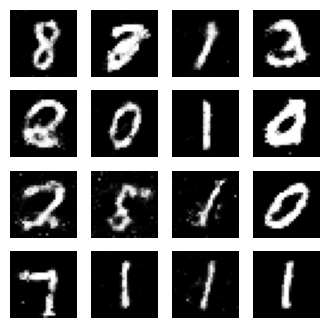

In [14]:
z = torch.randn(16, latent_size).to(device)
generated_images = G(z).view(-1, 1, 28, 28).cpu().detach()

plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.axis('off')
plt.show()

Incrível, não? Aqui, percebemos que a nossa querida GAN não terminou com uma resposta certa ou errada, mas com a capacidade de imaginar. Ela não guarda imagens; na verdade, ela aprende a estrutura dos dados. O Gerador agora é capaz de inventar exemplos coerentes a partir da distribuição dos dados originais e, no fim das contas, nossa rede não “chegou ao fim”. 

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
De uma forma mais bonita e encantadora, podemos dizer que a nossa GAN passou a existir por conta própria, criando dígitos que nunca foram escritos por ninguém... exceto pela matemática que a ensinou a sonhar.
</div>

Depois de observar as imagens geradas, é natural perguntar: como foi esse processo "por dentro"? Como foi a evolução do desempenho da nossa rede ao longo das épocas? Para responder a essa pergunta, precisamos olhar para as funções de perda do Discriminador e do Gerador ao longo do treinamento, pois são elas que contam a história da GAN de forma muito mais fiel do que um único conjunto de imagens finais.

---
### A curva de loss nos mostra a história dessa "generatividade"

A loss do Discriminador mede o quão bem ele consegue distinguir imagens reais das falsas. No início do treinamento, essa perda costuma ser baixa: o Discriminador aprende rapidamente a separar exemplos reais de imagens completamente sem sentido produzidas por um Gerador ainda imaturo. Nesse estágio, ele está “ganhando o jogo” com certa facilidade.

Já a loss do Gerador começa alta. Como ele recebe apenas ruído aleatório e ainda não sabe como transformá‑lo em algo plausível, suas imagens são facilmente rejeitadas. Cada erro do Discriminador, no entanto, serve como sinal de correção para o Gerador. É a partir dessas falhas que ele começa a aprender quais padrões tornam uma imagem mais convincente.

À medida que o treinamento avança, algo interessante acontece... o Discriminador deixa de melhorar tão rapidamente, porque as imagens falsas já não são tão obviamente falsas. Sua loss tende a oscilar, subindo quando o Gerador melhora e descendo quando consegue se readaptar. O Gerador, por sua vez, passa a apresentar uma loss mais estável, indicando que está cada vez melhor em enganar seu adversário.

Diferente de modelos tradicionais, essas perdas não convergem suavemente para zero. Oscilações são esperadas, e até mesmo são saudáveis. Elas refletem justamente o caráter competitivo do treinamento. Se uma das redes “vence demais”, a outra deixa de aprender, e o equilíbrio, nesse sentido, ocorre quando ambas se desafiam continuamente, sem que nenhuma domine completamente.

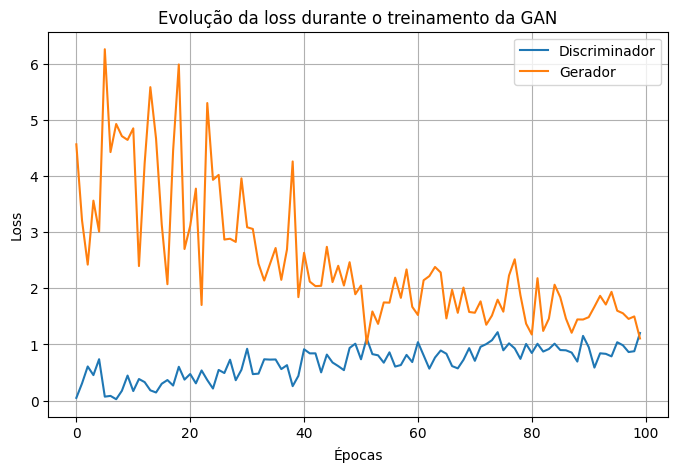

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(d_loss, label='Discriminador')
plt.plot(g_loss, label='Gerador')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Evolução da loss durante o treinamento da GAN')
plt.legend()
plt.grid(True)
plt.show()

O nosso gráfico demonstra muito bem o comportamento esperado, que foi descrito acima. 

A curva do Discriminador começa com valores relativamente baixos, próximos de zero. Isso indica que, no início, o Discriminador consegue diferenciar com facilidade as imagens reais das falsas, já que o Gerador ainda produz amostras pouco realistas. Com o avanço das épocas, essa loss cresce gradualmente e passa a oscilar em torno de valores mais altos. Esse aumento sinaliza que a tarefa do Discriminador se torna progressivamente mais difícil, pois as imagens geradas passam a se parecer cada vez mais com as reais.

A curva do Gerador, por sua vez, mostra que no início do treinamento sua loss é alta e com picos relevantes. Isso reflete o fato de que o Gerador está falhando em enganar o Discriminador, produzindo imagens facilmente identificáveis como falsas. Ao longo das épocas, no entanto, observa‑se uma tendência clara de queda na loss do Gerador, ainda que com fortes oscilações. Essas flutuações são esperadas e indicam os sucessivos ajustes entre as duas redes. Sempre que o Gerador melhora, o Discriminador aprende a responder, e vice‑versa.

Nas épocas finais, as duas curvas entram em um regime mais igualitário. A loss do Gerador se mantém em valores mais baixos do que no começo do treinamento, enquanto a loss do Discriminador permanece relativamente elevada e oscilante em relação ao seu início. O Gerador já não produz imagens obviamente falsas, e o Discriminador já não consegue classificá‑las com alta confiança.

Além disso, o gráfico mostra que o treinamento da nossa GAN não convergiu para perdas próximas de zero, como seria esperado em modelos supervisionados tradicionais. Porém, quando olhamos o histórico das perdas ao final do treinamento, o que buscamos não é uma vitória clara, mas um empate dinâmico, que foi o que aconteceu em nosso caso. É, portanto, esperado um cenário em que o Discriminador já não consegue diferenciar perfeitamente imagens reais e falsas, e o Gerador produz exemplos que pertencem à mesma distribuição dos dados reais, ainda que não sejam idênticos a nenhum deles.

Assim, as curvas de loss funcionam como um registro do "duelo/jogo" que moldou o comportamento da rede. Se as imagens finais mostram o que a rede aprendeu, as losses revelam como esse aprendizado aconteceu.

<div style="
  background-color:#fff4e5;
  border-left:6px solid #ff7f0e;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Por isso, atenção!</strong> Em GANs, a loss não precisa diminuir monotonicamente.
Oscilações são normais e fazem parte do jogo adversarial.
</div>

Mas além da observação da loss ao longo de diferentes épocas, lembram que eu propus um experimento diferente? Chegou o momento de colocá-lo em prática! Vamos observar as imagens geradas pela rede Geradora em diferentes pontos de treinamento para ver sua evolução. Bora!

## 11. O experimento: observando as imagens geradas em diferentes épocas

Acho que já deu para perceber que a proposta deste experimento é simples: capturar amostras de imagens produzidas pelo Gerador em diferentes épocas do treinamento e colocá‑las lado a lado. Para cada época escolhida, vamos observar um conjunto fixo de imagens, organizadas em uma grade, o que permite comparar visualmente como as saídas da rede mudam com o passar do tempo.

Para isso, defini a função `plotar_imagens()` na célula a seguir, que recebe dois elementos principais. O primeiro é um conjunto de imagens geradas pelo modelo, correspondente a uma mesma época do treinamento. Essas imagens são organizadas como um pequeno lote, permitindo observar várias amostras ao mesmo tempo. O segundo elemento é um título, usado apenas para contextualizar visualmente o que está sendo exibido, indicando se a época correspondente está na fase inicial, intermediária ou final do treinamento.

Ao ser executada, a função cria uma única figura e distribui as imagens em uma grade regular de 4 por 4. Porém, acessando diferentes conjuntos de imagens, gerados ao longo do loop de treinamento para diferentes épocas, podemos plotá-las e observar as incríveis diferenças de qualidade dos nossos resultados.

In [16]:
def plotar_imagens(imagens, titulo):
    plt.figure(figsize=(4, 4))
    for i in range(imagens.size(0)):
        plt.subplot(4, 4, i + 1)
        plt.imshow(imagens[i].view(28, 28), cmap='gray')
        plt.axis('off')
    plt.suptitle(titulo)
    plt.show()

Nas primeiras épocas, esperamos comprovar que as imagens geradas costumam se parecer pouco com dígitos reais. Elas provavelmente apresentarão formas não definidas, manchas irregulares e estruturas difíceis de interpretar. Isso é esperado pelo fato de o Gerador ainda não compreender a estrutura dos dados e estar apenas começando a transformar ruído aleatório em algo visual. Nesse estágio, a rede ainda “tenta adivinhar” o que poderia ser uma imagem plausível.

Conforme as épocas avançam, espera-se que padrões comecem a surgir. Teoricamente, traços mais definidos aparecerão, curvas passarão a lembrar partes de números, e as regiões claras e escuras se distribuirão de forma mais organizada. Mesmo quando os dígitos ainda não sejam claramente reconhecíveis, já será possível notar consistência entre as amostras, com o Gerador começando a respeitar as proporções e o estilo geral das imagens do conjunto de dados.

Nas épocas finais, a mudança tende a se tornar ainda mais evidente. Muitas imagens já podem ser identificadas como dígitos específicos, ainda que com imperfeições. Algumas são mais bem definidas do que outras, o que reflete o caráter estocástico do processo, em que pequenas variações no espaço latente levam a resultados visuais diferentes. Ainda assim, o conjunto como um todo se mantém coerente, indicando que o Gerador aprendeu a capturar a estrutura global da distribuição dos dados.

Vamos ver se nossas suposições se confirmam?

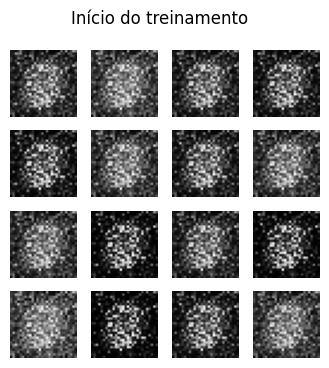

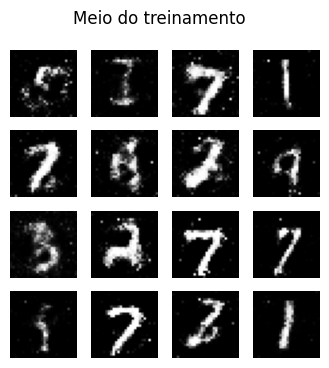

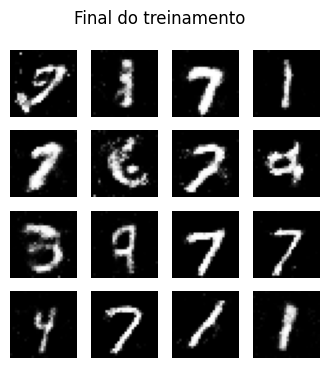

In [17]:
plotar_imagens(imagens_inicio, "Início do treinamento")
plotar_imagens(imagens_meio, "Meio do treinamento")
plotar_imagens(imagens_fim, "Final do treinamento")

Bom, dito e feito!

No início do treinamento, o Gerador produz imagens sem estrutura definida, refletindo o fato de que seus parâmetros ainda são essencialmente aleatórios. À medida que o treinamento avança, padrões começam a emergir nas imagens geradas, indicando que o Gerador está aprendendo características relevantes da distribuição dos dados reais. Ao final do treinamento, as imagens sintéticas apresentam maior coerência visual e semelhança com os dados reais, evidenciando o efeito do treinamento adversarial.

Observar essas imagens ao longo do treinamento deixa claro que o aprendizado da GAN não acontece de forma abrupta, mas gradual. Não há uma época exata em que o Gerador "aprende a gerar dígitos"; há, em vez disso, um processo contínuo de refinamento, guiado pela interação com o Discriminador. Esse experimento visual complementa a análise das losses: enquanto as curvas mostram quando a rede está se ajustando, as imagens mostram como esses ajustes se manifestam concretamente. Juntas, essas observações ajudam a compreender que o sucesso de uma GAN não está apenas em números estáveis, mas na capacidade progressiva de transformar ruído em algo reconhecível.

Em resumo: a evolução visual das imagens geradas evidencia o impacto do treinamento adversarial. Mesmo quando as perdas oscilam, o Gerador pode estar aprendendo estruturas cada vez mais complexas, o que reforça a importância de avaliar GANs também de forma qualitativa.

## 12. Quando tudo dá errado (e pode dar mesmo)

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Objetivo da seção</strong><br> Compreender os principais modos de falha no treinamento de GANs e entender por que esses comportamentos fazem parte da dinâmica adversarial.
</div>

O treinamento de GANs difere profundamente do treinamento de modelos supervisionados tradicionais. Como o aprendizado ocorre por meio de um jogo adversarial, não há garantia de convergência estável. Oscilações, falhas e resultados aparentemente incoerentes são não apenas comuns, mas esperados. Por isso, nesta seção, exploramos os principais cenários em que “tudo dá errado”, analisando o que acontece, por que acontece e como reconhecer cada situação.

### Mode collapse

O mode collapse [12] ocorre quando o Gerador passa a produzir amostras muito semelhantes entre si, ignorando grande parte da diversidade presente nos dados reais. Em casos extremos, diferentes vetores de ruído resultam praticamente na mesma saída. Do ponto de vista matemático, isso significa que o Gerador mapeia várias entradas $z$ distintas para uma mesma região do espaço de saída. Nesse caso, as imagens podem parecer visualmente razoáveis, mas a falta de diversidade indica que o modelo não aprendeu toda a distribuição dos dados.

### Imagens sem sentido (ruído persistente)

Outro problema frequente é o Gerador produzir imagens que parecem ruído puro ou padrões incoerentes, mesmo após muitas épocas de treinamento. Esse comportamento pode indicar:

*   Gerador fraco em relação ao Discriminador;
*   inicialização inadequada;
*   taxa de aprendizado muito alta ou muito baixa;
*   treinamento interrompido antes da formação de estruturas.

<div style="
  background-color:#fff4e5;
  border-left:6px solid #ff7f0e;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Atenção!</strong> Imagens ruins no início do treinamento são normais. O problema ocorre quando esse padrão persiste até o final.
</div>

### Discriminador forte demais

Se o Discriminador aprende muito rapidamente, ele passa a classificar corretamente quase todas as amostras. Nesse cenário, o Gerador recebe gradientes muito fracos, dificultando o aprendizado. Sintomas comuns:

*   loss do Discriminador próxima de zero;
*   loss do Gerador muito alta e quase constante;
*   imagens que não evoluem ao longo das épocas.

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Intuição</strong><br>
Se o juiz é perfeito desde o início, o falsificador não aprende nada novo.
</div>

### Oscilações excessivas nas perdas

Ao contrário de modelos supervisionados, GANs não apresentam convergência suave. Oscilações são normais, mas oscilações extremas e crescentes podem indicar instabilidade. Exemplos de comportamento problemático:

*   perdas explodem ou colapsam de forma abrupta;
*   alternância constante entre Gerador e Discriminador dominantes;
*   resultados visuais inconsistentes entre épocas próximas.

<div style="
  background-color:#fff4e5;
  border-left:6px solid #ff7f0e;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Atenção!</strong> Uma loss “bonita” não é garantia de boas imagens, e uma loss instável não implica necessariamente falha.
</div>

### Como identificar problemas corretamente

Um erro comum é avaliar GANs usando apenas a loss. No caso de GANs, como já discutimos e apresentamos ao longo deste notebook, o diagnóstico deve combinar a análise visual das amostras geradas, da diversidade entre imagens, da evolução ao longo do tempo e, em dados não visuais, da coerência estatística (com testes de hipótese, por exemplo).

As falhas discutidas nesta seção não são bugs acidentais, mas consequências diretas da formulação das GANs, já que os dois modelos competem simultaneamente, pequenas mudanças nos parâmetros podem alterar o equilíbrio e, além disso, não há uma solução única global facilmente (ou pelo menos rapidamente) alcançável.

### Por que estudar falhas é essencial?

Ignorar os modos de falha cria uma visão distorcida do que são modelos generativos. Reconhecer quando tudo dá errado é essencial para ajustar hiperparâmetros corretamente, escolher variantes mais estáveis (DCGAN e WGAN, por exemplo), interpretar resultados com senso crítico e compreender as limitações do método.

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Resumo</strong><br>
Mode collapse, imagens sem sentido, desequilíbrio entre Gerador e Discriminador e oscilações excessivas são falhas comuns no treinamento de GANs. Identificá‑las faz parte do processo de aprendizado e é essencial para o uso consciente de modelos generativos.
</div>

---

E foi exatamente a existência desses problemas motivou o desenvolvimento de extensões das GANs, que buscam maior estabilidade e melhor controle da diversidade. No próximo tópico, apresentamos algumas dessas variações e suas ideias centrais.

## 13. Extensões das GANs: além do modelo básico

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Objetivo da seção</strong><br> Apresentar extensões importantes das GANs que surgiram para lidar com limitações do modelo básico, destacando suas ideias centrais e aplicações típicas.
</div>

As dificuldades discutidas na seção anterior (instabilidade, mode collapse e sensibilidade a hiperparâmetros) motivaram o desenvolvimento de diversas extensões das GANs. Essas variantes mantêm a ideia central do treinamento adversarial, mas introduzem modificações na arquitetura, na função de perda ou no próprio jogo matemático, buscando maior estabilidade e controle.

Nesta seção, destacamos três extensões amplamente utilizadas: DCGAN, WGAN e GAN Condicional. Para saber sobre mais variações, recomendo que leia a referência [2].

### DCGAN - Deep Convolutional GAN

A DCGAN [8] foi uma das primeiras extensões bem-sucedidas das GANs e tem como ideia central substituir redes totalmente conectadas por redes neurais convolucionais profundas. Em vez de tratar imagens como vetores achatados, a DCGAN explora a estrutura espacial dos dados, utilizando:

*   convoluções no Discriminador;
*   convoluções transpostas no Gerador;
*   normalização em camadas intermediárias;
*   restrições estruturais simples, mas eficazes.

Isso porque se imagens possuem estrutura espacial, faz sentido usar arquiteturas que saibam explorá‑la. Então, entre as suas principais vantagens estão:

*   imagens visualmente mais nítidas;
*   treinamento mais estável do que GANs totalmente conectadas;
*   aprendizado de representações hierárquicas.

Na prática, DCGANs são indicadas quando o objetivo é gerar imagens e quando se deseja melhorar a qualidade visual sem alterar profundamente a lógica do treinamento adversarial.

---

Dada essa contextualização sobre as GANs convoluvionais, a seguir, apresentamos a implementação de uma DCGAN para o mesmo conjunto de dados, o MNIST. Porém, diferentemente das GANs totalmente conectadas, como já ressaltado, existem camadas convolucionais na arquitetura das redes discriminadora e geradora, permitindo que o modelo produza imagens explorando explicitamente a estrutura espacial dos dados.

### Um adendo: Convolução e Convolução Transposta

Antes de entender a arquitetura da DCGAN propriamente dita, é essencial compreender duas operações fundamentais em redes neurais profundas para imagens: convolução e convolução transposta. Embora os nomes sugiram operações complicadas, ambas podem ser interpretadas de forma bastante intuitiva quando pensamos em imagens como estruturas espaciais.

#### O que é uma convolução?

Uma convolução é uma operação que permite a uma rede neural extrair padrões locais de uma imagem. Em vez de analisar todos os pixels de uma vez, a convolução observa pequenas regiões da imagem por vez, chamadas de filtros (kernels).

Intuitivamente, um filtro convolucional funciona como uma espécie de lente especializada que desliza sobre a imagem, respondendo fortemente a determinados padrões locais, como bordas, curvas, texturas e contrastes. Cada filtro aprende automaticamente o que procurar durante o treinamento. O resultado da convolução é um mapa de ativação, que indica onde certos padrões aparecem na imagem.

Do ponto de vista estrutural, a convolução preserva a estrutura espacial da imagem (relações de vizinhança entre pixels) e reduz o número de parâmetros em comparação com camadas totalmente conectadas. Por essa razão, convoluções são especialmente adequadas para imagens, nas quais pixels próximos estão fortemente relacionados.

Em uma DCGAN, o Discriminador utiliza convoluções para responder à pergunta:

> “Esta imagem parece real?”

À medida que a imagem passa por sucessivas camadas convolucionais, a resolução espacial é gradualmente reduzida, as características extraídas se tornam mais abstratas e padrões locais simples dão lugar a estruturas globais mais complexas. Assim, a convolução permite ao Discriminador aprender o que torna uma imagem realista, sem precisar analisar todos os pixels de forma independente, como no caso da GAN convencional.

#### O que é uma convolução transposta?

A convolução transposta desempenha o papel oposto ao da convolução tradicional. Enquanto a convolução reduz a resolução de uma imagem, a convolução transposta é usada para aumentar a resolução. Em termos intuitivos, pode-se dizer que a convolução compressa uma imagem e a convolução transposta expande uma imagem. Ela faz isso aprendendo como espalhar informações de um mapa pequeno para um mapa maior, preenchendo gradualmente os detalhes espaciais.

Nesse contexto, temos que, na DCGAN, o Gerador começa com um vetor de ruído aleatório, que não possui estrutura espacial. Esse vetor é reinterpretado como um pequeno mapa de características e, em seguida, passa por uma sequência de convoluções transpostas. A cada etapa, a resolução da imagem aumenta, novos detalhes espaciais são adicionados e padrões mais refinados são aprendidos.

O processo pode ser visto como uma construção gradual da imagem, partindo de uma representação abstrata e compacta até uma imagem final completa. Em termos conceituais, o Gerador utiliza a convolução transposta para responder à pergunta:

> “Como transformar um vetor aleatório em uma imagem plausível?”

---
Agora, vamos entender mais detalhadamente o funcionamento das GANs.

### Um desafio para quem quer ir além: explorando na prática as DCGANs

Na célula abaixo, começamos a criar nossa rede DCGAN, definindo a classe da rede Geradora. Ela, como na GAN convencional, é responsável por transformar um vetor de ruído aleatório em uma imagem sintética que se assemelhe às imagens reais do conjunto de dados. Contudo, difere de uma GAN totalmente conectada pelo fato de não tratar a imagem como um vetor achatado; em vez disso, ele constrói a imagem de forma progressiva, explorando explicitamente a estrutura espacial dos pixels, por meio da convolução.

A entrada do Gerador é um vetor de ruído latente, no qual cada amostra corresponde a um ponto em um espaço latente de dimensão latent_size. Esse vetor não possui significado visual direto; ele funciona como uma semente abstrata a partir da qual a rede aprende a construir imagens plausíveis, explorando regularidades estatísticas presentes no conjunto de dados.

A primeira camada do Gerador aplica uma convolução transposta que expande esse vetor de ruído em um mapa de ativação bidimensional com maior estrutura espacial. No caso desta arquitetura, o ruído é projetado diretamente em um mapa de dimensão $7 \times 7$ com 256 canais. Essa etapa pode ser interpretada como a primeira organização espacial do ruído, onde o modelo começa a transformar um vetor puramente aleatório em uma representação estrutural inicial da imagem. A aplicação da normalização em lote logo após essa camada contribui para estabilizar o treinamento, controlando a escala das ativações e facilitando a propagação do gradiente.

Nas camadas seguintes, o Gerador realiza um processo de upsampling gradual por meio de convoluções transpostas com stride maior que 1. Essas operações aumentam progressivamente a resolução espacial dos mapas de ativação, até chegar à resolução original das imagens do conjunto MNIST. Ao longo desse processo, observa‑se uma redução no número de canais, enquanto a resolução espacial aumenta, permitindo que a rede refine gradualmente os detalhes da imagem gerada. 

As funções de ativação do tipo ReLU são utilizadas nas camadas intermediárias para introduzir não linearidades e favorecer gradientes mais estáveis durante o treinamento. Já a camada final utiliza a função de ativação Tanh, que garante que os valores de saída estejam no intervalo $[−1,1]$, compatível com a normalização aplicada às imagens reais durante o treinamento.

**OBS.:** Os códigos referentes às DCGANs foram adaptados da referência [8].

In [19]:
class Generator_DCGAN(nn.Module):
    def __init__(self, latent_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_size, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

De forma geral, essa arquitetura ilustra bem os princípios centrais da DCGAN: o uso exclusivo de camadas convolucionais, mais especificamente de camadas convolucionais transpostas, a construção hierárquica da imagem a partir de ruído e a adoção de práticas simples, como normalização em lote, e escolhas adequadas de funções de ativação, que resultam em treinamento mais estável e imagens visualmente mais coerentes. Assim, o gerador não “desenha” a imagem de uma só vez, mas a constrói progressivamente, aprendendo padrões espaciais em diferentes escalas.

---
### Normalização em lote? De onde surgiu isso?

A normalização em lote (*Batch Normalization*) é uma técnica usada em redes neurais para estabilizar o treinamento ao controlar a distribuição das ativações internas da rede. Ela atua normalizando as saídas de uma camada com base nas estatísticas do mini‑batch, ajustando esses valores para terem média aproximadamente zero e variância próxima de um. Em seguida, a própria rede aprende parâmetros de escala e deslocamento, preservando sua capacidade expressiva.

<div align="center">
<img src="https://media.datacamp.com/cms/google/qhzkx6h86pv_p0bwfol6mwnan8mgrvrxim3rx3kua96fe9uzxxjsuxvse-pgc__sbn_0tt4kerhukjfii5m1y30s7-yo3d-x8ydonmkedt9ld2qarcgua6ga-vyzjow2coh5ibu1ucbbaf11_yscbn8.png">

    Figura 3. Normalização em lote. Fonte: https://www.datacamp.com/pt/tutorial/batch-normalization-tensorflow
</div><br>

Na prática, essa normalização reduz variações excessivas ao longo do treinamento, melhora o fluxo de gradientes e torna o aprendizado mais estável e rápido. Como consequência, a rede se torna menos sensível à inicialização dos pesos e a oscilações abruptas durante a otimização.

---

### Depois da pausa para os comerciais... a rede discriminadora!

O discriminador é definido na célula a seguir. Ele tem como função avaliar se uma imagem apresentada é real, proveniente do conjunto de dados, ou falsa, gerada pelo modelo adversário. Ele atua como um classificador binário, atribuindo a cada imagem uma probabilidade de ser real. Assim como no gerador, a principal diferença em relação às GANs totalmente conectadas está no uso de camadas convolucionais, que permitem explorar diretamente a estrutura espacial das imagens. Estou reforçando isso propositalmente, para lembrarmos o porquê de obtermos os resultados a seguir!

A entrada do discriminador é uma imagem correspondente a imagens em escala de cinza do conjunto MNIST. Em vez de achatar essa imagem em um vetor, o modelo começa aplicando uma convolução que reduz simultaneamente a resolução espacial e extrai características locais. Essa primeira camada transforma a imagem, aumentando o número de canais e aprendendo padrões básicos, como bordas e traços simples.

Após essa convolução inicial, utiliza-se a função de ativação LeakyReLU, que permite um pequeno gradiente mesmo para valores negativos. Essa escolha é especialmente importante no discriminador, pois reduz o risco de unidades “mortas” e contribui para um fluxo de gradiente mais estável durante o treinamento adversarial. Diferentemente do gerador, não se aplica normalização em lote nessa primeira camada, seguindo as boas práticas propostas originalmente para DCGANs, uma vez que a normalização em camadas iniciais do discriminador pode prejudicar sua capacidade de distinguir imagens reais de falsas.

Na sequência, uma segunda convolução aprofunda a extração de características, reduzindo novamente a resolução espacial e aumentando o número de canais. Nessa etapa, o modelo aprende representações mais abstratas da imagem, combinando padrões simples para identificar estruturas mais complexas. A normalização em lote passa a ser utilizada a partir dessa camada, ajudando a estabilizar o treinamento e a tornar a distribuição das ativações mais controlada.

A etapa final do discriminador consiste em uma convolução que reduz toda a informação espacial restante a um único valor, resultando em um tensor. Esse valor pode ser interpretado como uma evidência global da autenticidade da imagem. A aplicação da função Sigmoid na saída transforma esse valor em uma probabilidade no intervalo $[0, 1]$, indicando quão provável é que a imagem seja real segundo o discriminador.

Por fim, o método `forward()` apenas reorganiza a saída para o formato $(N, 1)$, facilitando o cálculo da função de perda binária durante o treinamento. De maneira geral, o discriminador da DCGAN atua como o contraponto direto ao gerador. Enquanto o gerador tenta produzir imagens cada vez mais realistas, o discriminador refina sua capacidade de detecção explorando hierarquicamente a estrutura espacial das imagens. Esse equilíbrio adversarial é o que permite à DCGAN aprender representações visuais cada vez mais coerentes ao longo do treinamento. A lógica, no final das contas, é a mesma!

In [20]:
class Discriminator_DCGAN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 1, 7, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

### As funções ReLU e LeakyReLU nos perseguem...

Nas DCGANs, o Gerador utiliza predominantemente ReLU nas camadas intermediárias, pois seu objetivo é amplificar e combinar características de forma robusta à medida que a imagem é construída. Já o Discriminador utiliza LeakyReLU para manter um fluxo de gradiente consistente e evitar a perda de unidades durante o treinamento adversarial.

Essa combinação reflete uma separação de papéis: o gerador se beneficia da simplicidade e eficiência da ReLU para criar estruturas progressivamente mais complexas, enquanto o discriminador exige maior sensibilidade e estabilidade, fornecida pela LeakyReLU. Assim, a escolha das funções de ativação contribui diretamente para a estabilidade e o sucesso do treinamento das DCGANs.

Em resumo, a ReLU e a LeakyReLU desempenham papéis complementares nas redes neurais profundas. A ReLU favorece aprendizado eficiente e rápido, mas pode sofrer com neurônios inativos. A LeakyReLU, ao permitir gradientes não nulos em regiões negativas, oferece maior robustez, especialmente em cenários adversariais. Em modelos como as DCGANs, essas escolhas refletem não apenas preferências empíricas, mas uma compreensão profunda das dinâmicas de aprendizado envolvidas no treinamento de redes generativas profundas.

---
### Afinal, por que as operações de convolução são essenciais em GANs convolucionais?

Sem convoluções, uma GAN trataria uma imagem apenas como um vetor de números, ignorando completamente a geometria do problema, como ocorreu quando treinamos uma GAN convencional. Com convoluções e convoluções transpostas, o modelo passa a respeitar a organização espacial dos dados, o que resulta em imagens mais nítidas, padrões mais realistas e treinamento mais estável.

Essa é a principal razão pela qual DCGANs representam um avanço significativo em relação às GANs totalmente conectadas no contexto de imagens.

---

Com as classes das redes adversárias devidamente definidas, e tendo entendido as vantagens de estruturar uma GAN com camadas convolucionais para problemas de geração envolvendo imagens, passamos para a etapa de criação de uma função distinta, que não era necessária no contexto das GANs convencionais. Essa função, chamada de `weights_init()`, é responsável por inicializar os pesos das camadas da rede de acordo com as recomendações clássicas para o treinamento de DCGANs. A forma como os pesos iniciais são escolhidos exerce grande influência na estabilidade do treinamento, especialmente em arquiteturas adversariais, nas quais pequenos desequilíbrios podem levar a problemas como gradientes instáveis ou colapso de modos.

A função atua de maneira genérica, recebendo como entrada um módulo da rede e identificando seu tipo a partir do nome da classe. Quando o módulo corresponde a uma camada convolucional, seja ela uma convolução padrão ou uma convolução transposta, seus pesos são inicializados a partir de uma distribuição normal com média zero e desvio padrão pequeno. Essa escolha evita que as ativações iniciais sejam excessivamente grandes ou pequenas, favorecendo um início de treinamento mais controlado tanto para o gerador quanto para o discriminador.

No caso das camadas de normalização em lote (*Batch Normalization*), a inicialização segue uma lógica ligeiramente diferente. Os pesos associados à normalização são inicializados com média um e pequeno desvio padrão, o que faz com que a camada, inicialmente, atue de forma próxima a uma identidade. Isso permite que a normalização estabilize as ativações sem distorcer significativamente a informação nas primeiras etapas do treinamento. Os termos de viés dessas camadas são inicializados como zero, garantindo que não haja deslocamentos artificiais na distribuição das ativações.

In [21]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

Essa estratégia de inicialização não é arbitrária: ela foi proposta na referência que utilizei sobre DCGAN e é uma prática padrão na literatura. Ao aplicar essa função a todas as camadas do gerador e do discriminador antes do treinamento, garante-se que ambas as redes comecem o processo adversarial em condições semelhantes e estáveis. Como resultado, o treinamento tende a ser mais suave, com menor risco de divergência precoce ou comportamento degenerado das redes.

Logo, a função `weights_init()` desempenha um papel fundamental na preparação do modelo para o treinamento adversarial, contribuindo diretamente para a estabilidade e eficiência do aprendizado da DCGAN.

---
Agora, podemos finalmente partir para o treino da nossa rede. Porém, quero fazer o mesmo experimento que fiz anteriormente na aplicação das GANs convencionais, mostrando imagens geradas em diferentes épocas. Para isso, na próxima célula, estou...

### Definindo mais parâmetros

O parâmetro `num_examples` determina quantas imagens serão geradas e exibidas ao longo do treinamento. No caso apresentado, escolhem-se 16 exemplos, o que permite organizar as imagens em uma grade $4 \times 4$, facilitando a comparação visual entre diferentes momentos do treinamento e mantendo o padrão anteriormente adotado. Essa escolha é puramente prática, definida como padrão em nosso notebook, mas pode ser ajustada conforme a quantidade de imagens que se deseja analisar.

Já o tensor `fixed_noise` é amostrado a partir de uma distribuição normal padrão e possui dimensão $(16, \text{latent\_size}, 1, 1)$. Esse formato é compatível com a arquitetura do gerador da DCGAN, que espera como entrada um vetor de ruído com estrutura espacial mínima, a partir do qual as convoluções transpostas realizam o processo de expansão progressiva até o tamanho final da imagem. A inclusão explícita das dimensões $1 \times 1$ reforça a interpretação do ruído como um “mapa” inicial sem estrutura espacial, que será gradualmente transformado pela rede.

Ao manter esse ruído constante durante todo o treinamento, é possível observar como o gerador melhora suas saídas ao longo das épocas sem introduzir variabilidade adicional causada pela troca dos vetores latentes. Dessa forma, qualquer mudança observada nas imagens geradas pode ser atribuída diretamente ao aprendizado do modelo, e não a diferenças no ruído de entrada. Isso torna a análise da convergência visual do gerador mais clara e interpretável.

In [22]:
# Número de imagens que queremos visualizar
num_examples = 16

# Ruído fixo para acompanhar a evolução do Gerador
fixed_noise = torch.randn(num_examples, latent_size, 1, 1).to(device)

### Agora sim! Inicializando as nossas redes geradora e discriminadora...

Assim como fizemos para as redes `G` e `D` um pouco mais cedo, instanciamos nossas redes `G_DCGAN` e `D_DCGAN` como objetos das classes que acabamos de definir. Em seguida, aplicou-se a função `weights_init()` a cada um dos modelos por meio do método `apply()`. Esse procedimento percorre recursivamente todas as camadas internas do gerador e do discriminador, inicializando seus pesos de acordo com a estratégia definida anteriormente. Dessa forma, cada camada convolucional e cada camada de normalização em lote recebe valores iniciais cuidadosamente escolhidos para favorecer a estabilidade do treinamento adversarial.

Essa etapa é particularmente importante no contexto das DCGANs, pois o equilíbrio inicial entre gerador e discriminador influencia diretamente a dinâmica do jogo adversarial. Uma inicialização inadequada pode fazer com que uma das redes se torne dominante muito cedo, prejudicando o aprendizado da outra. Ao utilizar a inicialização recomendada na literatura, ambos os modelos partem de condições comparáveis, com distribuições de pesos bem comportadas.

Assim, a criação dos modelos seguida da aplicação sistemática da inicialização de pesos garante que o treinamento da DCGAN comece de forma controlada e estável. Esse cuidado inicial, embora simples, tem impacto direto na qualidade das imagens geradas e na suavidade da convergência observada ao longo das épocas, sendo uma prática essencial em implementações bem‑sucedidas de GANs convolucionais.

In [23]:
G_DCGAN = Generator_DCGAN(latent_size).to(device)
D_DCGAN = Discriminator_DCGAN().to(device)

G_DCGAN.apply(weights_init)
D_DCGAN.apply(weights_init)

Discriminator_DCGAN(
  (net): Sequential(
    (0): Conv2d(1, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(256, 1, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (6): Sigmoid()
  )
)

Depois, definimos a loss function e os otimizadores das redes geradora e discrimidora. Novamente, optamos pela BCELoss e pelo otimizador Adam, por se mostrarem bem eficientes ao nosso contexto.

Porém, note que agora adicionamos aos otimizadores da DCGAN os parâmetros `betas` do método Adam, responsáveis por controlar como o algoritmo incorpora informações dos gradientes ao longo do tempo. Esses valores definem o peso dado às médias móveis do gradiente e do quadrado do gradiente, influenciando a forma como as atualizações dos parâmetros acumulam memória do passado.

O primeiro valor, $\beta_1 = 0{,}5$, regula o termo de momento, determinando o quanto os gradientes anteriores influenciam a direção da atualização atual. O segundo valor, $\beta_2 = 0{,}999$, controla a média móvel do quadrado dos gradientes, que ajusta a escala das atualizações. Em conjunto, a escolha de `betas=(0.5, 0.999)` representa um compromisso entre estabilidade e adaptabilidade, sendo amplamente adotada em DCGANs para tornar o treinamento adversarial mais robusto.

In [24]:
fn_perda_DCGAN = nn.BCELoss()

optimizer_G_DCGAN = torch.optim.Adam(G_DCGAN.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D_DCGAN = torch.optim.Adam(D_DCGAN.parameters(), lr=lr, betas=(0.5, 0.999))

---
Em seguida, para facilitar a lógica de treinamento da DCGAN, definimos uma nova função.

Em relação à utilizada para a GAN convencional, a função `train_dcgan()` apresenta algumas diferenças fundamentais que refletem diretamente a mudança de arquitetura para uma DCGAN. A principal alteração, nesse sentido, está na forma como os dados são manipulados. Enquanto na GAN tradicional as imagens são previamente achatadas em vetores unidimensionais, na DCGAN as imagens são mantidas em seu formato original bidimensional, preservando a estrutura espacial necessária para o uso de camadas convolucionais. Consequentemente, o vetor de ruído latente também passa a ser tratado como um tensor de quatro dimensões, com formato $(N, \text{latent\_size}, 1, 1)$, tornando-se compatível com as convoluções transpostas do gerador.

Então, embora a lógica adversarial básica seja preservada, a função `train_dcgan()` reflete as adaptações necessárias para acomodar arquiteturas convolucionais profundas, especialmente quanto aos detalhes relacionados às dimensões, alinhando o procedimento de treinamento às características específicas das DCGANs.

In [25]:
def train_dcgan(G, D, dataloader, fn_perda, optimizer_G, optimizer_D, device, num_epochs, latent_size, fixed_noise):
    losses_G = []
    losses_D = []
    # Variáveis para armazenar imagens de diferentes momentos
    imagens_inicio = None
    imagens_meio = None
    imagens_fim = None
    
    for epoch in range(num_epochs):
        for i, (images, _) in enumerate(dataloader):
            images = images.to(device)
            batch_size = images.size(0)

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            optimizer_D.zero_grad()

            # Imagens reais
            outputs_real = D(images)
            loss_real = fn_perda(outputs_real, real_labels)

            # Imagens falsas
            z = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = G(z)
            outputs_fake = D(fake_images.detach())
            loss_fake = fn_perda(outputs_fake, fake_labels)

            loss_D = loss_real + loss_fake
            loss_D.backward()
            optimizer_D.step()

            # Treinamento do Gerador
            optimizer_G.zero_grad()

            z = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = G(z)
            outputs = D(fake_images)

            loss_G = fn_perda(outputs, real_labels)
            loss_G.backward()
            optimizer_G.step()

        losses_D.append(loss_D.item())
        losses_G.append(loss_G.item())

        # Salvar imagens em épocas específicas
        if epoch == 0:
            imagens_inicio = gerar_imagens(G, fixed_noise)

        if epoch == num_epochs // 2:
            imagens_meio = gerar_imagens(G, fixed_noise)

        if epoch == num_epochs - 1:
            imagens_fim = gerar_imagens(G, fixed_noise)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Loss D: {loss_D.item():.4f} | "
            f"Loss G: {loss_G.item():.4f}"
        )

    return (losses_G, losses_D, imagens_inicio, imagens_meio, imagens_fim)

Agora sim! Mãos na massa!

Vamos treinar nossa DCGAN por dez épocas e ver o que acontece.

In [26]:
num_epochs = 10

In [28]:
losses_G, losses_D, imagens_inicio, imagens_meio, imagens_fim = train_dcgan(
    G=G_DCGAN,
    D=D_DCGAN,
    dataloader=train_loader,
    fn_perda=fn_perda_DCGAN,
    optimizer_G=optimizer_G_DCGAN,
    optimizer_D=optimizer_D_DCGAN,
    device=device,
    num_epochs=num_epochs,
    latent_size=latent_size,
    fixed_noise=fixed_noise
)

Epoch [1/10] Loss D: 0.5787 | Loss G: 1.3656
Epoch [2/10] Loss D: 0.8100 | Loss G: 2.1579
Epoch [3/10] Loss D: 0.3637 | Loss G: 1.7566
Epoch [4/10] Loss D: 0.4535 | Loss G: 1.6907
Epoch [5/10] Loss D: 0.6666 | Loss G: 1.7194
Epoch [6/10] Loss D: 0.7227 | Loss G: 2.3831
Epoch [7/10] Loss D: 0.5749 | Loss G: 2.2704
Epoch [8/10] Loss D: 0.6778 | Loss G: 2.1966
Epoch [9/10] Loss D: 0.5030 | Loss G: 1.1384
Epoch [10/10] Loss D: 0.4100 | Loss G: 2.7177


#### Uma pequena observação! Por que treinei a DCGAN por apenas dez épocas?

Neste notebook, o objetivo principal não é obter as melhores imagens possíveis, mas compreender o funcionamento conceitual de uma GAN: como o aprendizado começa, como a dinâmica adversarial se estabelece e como o Gerador transforma ruído em estrutura ao longo do tempo. Dentro dessa proposta, o treinamento por apenas dez épocas é uma escolha exclusivamente pedagógica.

Nas primeiras épocas, a DCGAN encontra‑se em seu estado mais cru. O Gerador ainda não aprendeu a estrutura do conjunto de dados e produz imagens que se assemelham fortemente a ruído. O Discriminador, por sua vez, consegue distinguir com facilidade imagens reais e falsas, apresentando um desempenho artificialmente alto. Esse cenário inicial é particularmente valioso do ponto de vista didático, pois evidencia que a GAN não nasce sabendo gerar imagens: ela começa falhando, e aprende justamente a partir dessas falhas.

Treinar por poucas épocas permite observar esse ponto de partida com clareza. As imagens geradas após dez épocas mostram o estágio inicial do aprendizado, quando ainda não há dígitos reconhecíveis, mas já começam a surgir indícios de estrutura espacial. Esse momento é essencial para entender que o aprendizado em GANs é um processo gradual, cumulativo e instável, e não um salto imediato do ruído para imagens realistas. Porém, mostra também, compartivamente às GANs convencionais, que as DCGANs conseguem obter um desempenho melhor logo de início.

Há também uma outra justificativa prática importante. O treinamento de GANs pode ser computacionalmente custoso, mesmo em conjuntos de dados simples como o MNIST. Utilizar apenas dez épocas torna o notebook mais acessível, reprodutível e eficiente, permitindo que o foco permaneça na interpretação conceitual dos resultados, e não no tempo de execução.

Por fim, é importante enfatizar que este treinamento reduzido não representa um modelo final, mas sim um recorte intencional do processo de aprendizado. Ele funciona como um experimento controlado, que revela o início da trajetória da GAN. Ao contrastar essas primeiras épocas com treinamentos mais longos em seções posteriores, o leitor pode compreender melhor a transformação progressiva do Gerador e o papel central da dinâmica adversarial.

---
Rede treinada, losses calculadas e justificativas fornecidas... bora visualizar os resultados?

### Visualizando a evolução da loss

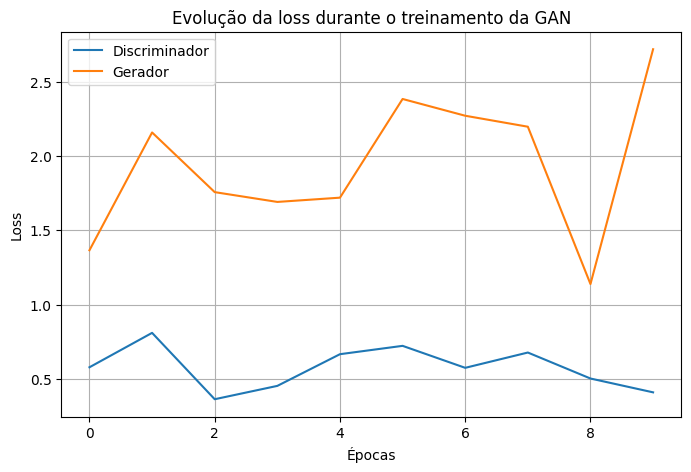

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(losses_D, label='Discriminador')
plt.plot(losses_G, label='Gerador')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Evolução da loss durante o treinamento da GAN')
plt.legend()
plt.grid(True)
plt.show()

Como primeira análise, temos que, no gráfico, a loss do Discriminador permanece relativamente mais baixa e oscila em torno de valores intermediários, indicando que ele está conseguindo distinguir, ao menos parcialmente, imagens reais das imagens geradas (porque estamos considerando somente as dez épocas iniciais). Oscilações moderadas nessa curva são esperadas, pois a dificuldade da tarefa muda conforme o Gerador melhora ou piora momentaneamente suas amostras. Assim como numa GAN convencional, quando o Gerador produz imagens mais convincentes, a loss do Discriminador tende a aumentar; quando o Gerador falha, a loss do Discriminador diminui.

A loss do Gerador, por sua vez, apresenta variações mais pronunciadas. Isso reflete o fato de que o Gerador depende inteiramente da resposta do Discriminador para aprender. Picos na loss do Gerador indicam momentos em que o Discriminador conseguiu classificá‑lo com facilidade, enquanto quedas sugerem que o Gerador passou a enganá‑lo com maior sucesso. 

Essas flutuações são típicas do treinamento de DCGANs e não devem ser interpretadas, isoladamente, como sinais de falha. Por isso, vamos visualizar as imagens ao longo das diferentes épocas?

### Acompanhando as imagens geradas ao longo de diferentes épocas do treinamento

Uma função adapatada para plotar as imagens do nosso experimento...

In [33]:
def plotar_imagens_DCGAN(imagens, titulo, nrow=4):
    """
    imagens: tensor (N, 1, 28, 28) em [-1, 1]
    """
    imagens = (imagens + 1) / 2

    plt.figure(figsize=(4, 4))
    for i in range(imagens.size(0)):
        plt.subplot(nrow, nrow, i + 1)
        plt.imshow(imagens[i, 0], cmap='gray')
        plt.axis('off')

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

Voilà!

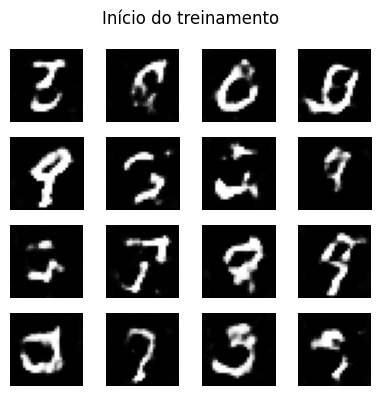

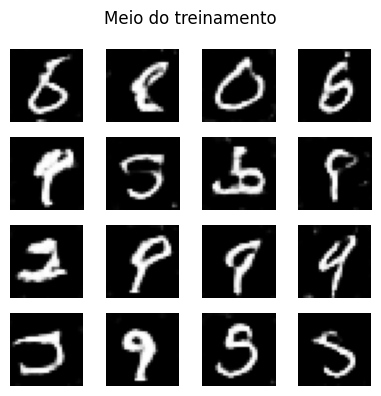

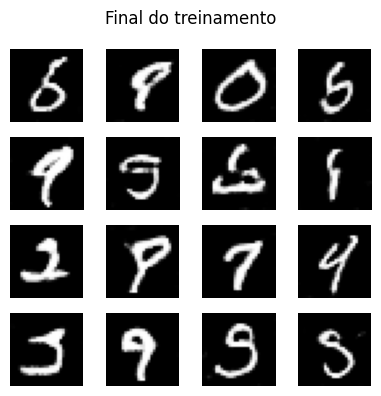

In [34]:
plotar_imagens_DCGAN(imagens_inicio, "Início do treinamento")
plotar_imagens_DCGAN(imagens_meio, "Meio do treinamento")
plotar_imagens_DCGAN(imagens_fim, "Final do treinamento")

As imagens geradas evidenciam que a DCGAN atinge resultados visualmente muito satisfatórios mesmo com um número relativamente reduzido de épocas de treinamento. Já nas fases intermediárias (e até mesmo nas iniciais, se formos parar para ver), é possível observar dígitos bem formados, com traços contínuos, boa separação entre fundo e objeto e estruturas coerentes com a escrita manual do MNIST. Ao final do treinamento, essa qualidade se consolida, revelando amostras claramente reconhecíveis e diversas, sem a necessidade de um treinamento excessivamente prolongado.

Esse desempenho com poucas épocas contrasta com o que normalmente se observa em uma GAN totalmente conectada, que costuma exigir mais tempo de treinamento para produzir imagens minimamente estruturadas e, ainda assim, frequentemente apresenta borramento, ruído residual ou formas pouco consistentes. A DCGAN, por explorar explicitamente a estrutura espacial das imagens por meio de convoluções e convoluções transpostas, aprende padrões relevantes de forma mais eficiente, organizando rapidamente o ruído latente em traços e contornos significativos.

Assim, os resultados reforçam que a principal vantagem da DCGAN não está apenas na qualidade final das imagens, mas também na velocidade (em questão de número de épocas) com que essa qualidade emerge. Mesmo com menos épocas, o modelo já produz amostras plausíveis e interpretáveis, o que demonstra maior eficiência de aprendizado e melhor aproveitamento da informação contida nos dados visuais. Isso torna a DCGAN especialmente atraente em contextos didáticos e experimentais, nos quais deseja‑se observar rapidamente a transição do ruído para imagens coerentes.

---

Como as DCGANs são lindas, não é mesmo?

Com elas, percebemos que uma estratégia de rede neural muito bem pensada e eficiente pode se tornar ainda melhor. Porém, não para por aí... os outros dois tipos de GANs que eu gostaria de comentar também são os seguintes [2]:

### WGAN - Wasserstein GAN

A Wasserstein GAN (WGAN) propõe uma mudança conceitual mais profunda. Em vez de utilizar a divergência implícita da cross‑entropy, ela redefine o jogo utilizando a distância de Wasserstein, uma métrica mais estável para comparar distribuições de probabilidade. Com isso:

*   o Discriminador passa a ser chamado de Crítico;
*   a saída não representa mais uma probabilidade;
*   a função de perda fornece gradientes mais informativos.

Em vez de perguntar “isso parece real?”, que é a base da rede discriminadora, o Crítico pergunta “quão diferente isso é do real?”. Como suas principais vantagens, apresentam-se:

*   maior estabilidade de treinamento;
*   redução significativa de mode collapse;
*   interpretação mais consistente da loss ao longo do tempo.

Para garantir propriedades matemáticas desejáveis, a WGAN impõe restrições adicionais, como limitação de pesos ou penalidade de gradiente (WGAN‑GP). Então, as WGANs são especialmente indicadas quando a GAN básica apresenta instabilidade persistente e dificuldade de convergência.

### GANs condicionais

As GANs condicionais introduzem uma ideia simples, porém poderosa: controlar o processo de geração fornecendo informações adicionais ao modelo. Além do ruído aleatório $z$, o Gerador e o Discriminador recebem uma condição $c$, como:

*   a classe do dígito (no caso do MNIST);
*   o tipo de objeto a ser gerado;
*   uma informação contextual relevante.

Logo, em vez de gerar qualquer coisa plausível, a GAN aprende a gerar algo específico sob demanda. Para entendermos melhor, um exemplo de aplicação desse tipo de GAN seria uma situação em que quero gerar apenas dígitos “3”, ou apenas imagens associadas a uma determinada classe. Portanto, como principais vantagens encontram-se o maior controle sobre as amostras geradas, o melhor aproveitamento de informações disponíveis e a redução de ambiguidades no aprendizado.

Em suma, as GANs condicionais são ideais quando há informação adicional estruturada e quando o objetivo é direcionar o processo de geração.

*   **DCGAN:** melhora a arquitetura, mantendo o jogo original
*   **WGAN:** altera o jogo matemático para ganhar estabilidade
*   **GAN Condicional:** adiciona controle ao processo de geração

Reforço que o modelo básico estudado neste notebook fornece a base conceitual necessária para compreender todas essas extensões. Embora as arquiteturas e funções de perda mudem, os elementos centrais permanecem um Gerador tentando criar dados realistas, um oponente avaliando essas criações e o aprendizado emergindo da competição.

<div style="
  background-color:#e8f2ff;
  border-left:6px solid #1f77b4;
  padding:12px;
  margin:15px 0;
  border-radius:6px;
">
<strong>Resumo</strong><br>
DCGANs, WGANs e GANs condicionais surgiram para lidar com limitações práticas das GANs básicas, oferecendo maior estabilidade, melhor qualidade visual ou maior controle sobre o processo de geração.
</div>

Para o leitor curioso, fica o desafio de aplicar esses dois tipos de redes não explorados em código aqui neste notebook para o mesmo conjunto de dados, adaptando as estratégias e avaliando os seus desempenhos!

---

Com isso, concluímos (por enquanto) a jornada pelas Redes Neurais Generativas Adversariais, passando da intuição inicial até a implementação prática e suas extensões modernas. O leitor agora possui uma base sólida para explorar modelos generativos de forma crítica e informada.

## 14. Conclusão

Ao longo deste material, foi apresentada uma introdução conceitual, matemática e prática às Redes Neurais Generativas Adversariais (GANs), partindo de uma motivação intuitiva até a implementação concreta de um modelo funcional. Em vez de abordar as GANs apenas como uma técnica avançada de aprendizado profundo, buscou-se enfatizar a mudança de paradigma que elas representam: modelos que não apenas analisam dados existentes, mas são capazes de gerar novos dados plausíveis, aprendendo diretamente a estrutura da distribuição real.

A construção do material priorizou uma progressão cuidadosa, partindo da metáfora do jogo entre Gerador e Discriminador, passando pela formalização matemática do problema minimax, até a tradução dessas ideias em código executável. Essa abordagem permitiu conectar intuição, teoria e prática, reduzindo a sensação de “caixa‑preta” frequentemente associada às GANs. A análise do loop de treinamento e o acompanhamento visual da evolução das imagens geradas reforçaram a compreensão de que o aprendizado emerge da dinâmica adversarial, e não da busca por uma resposta correta única.

Além disso, a exploração dos modos de falha (como mode collapse, instabilidade e imagens sem sentido) teve um papel central ao explicitar as limitações do método. Ao reconhecer que “tudo pode dar errado”, torna‑se possível interpretar resultados com senso crítico e compreender por que tantas extensões das GANs foram propostas. Nesse contexto, a discussão sobre DCGANs, WGANs e GANs condicionais mostrou como a pesquisa na área avança justamente a partir desses desafios, refinando o jogo adversarial para torná‑lo mais estável, controlável e útil.

## 15. Checklist do seu aprendizado

Ao final deste percurso, espera‑se que o leitor não apenas saiba implementar uma GAN básica, mas também compreenda:

*   o que o modelo está efetivamente aprendendo;
*   por que o treinamento é instável;
*   como interpretar perdas e resultados visuais;
*   quando faz sentido recorrer a variantes mais sofisticadas.

Mais do que dominar uma técnica específica, o objetivo foi construir uma base conceitual sólida sobre modelagem generativa, preparando o estudante para explorar, de forma autônoma e crítica, modelos mais avançados e aplicações reais. As GANs, com todas as suas virtudes e dificuldades, servem assim como um excelente laboratório para compreender tanto o potencial quanto os limites do aprendizado de máquina moderno.

### Coisas a se pensar (cenas para o próximo capítulo)

*   Como a introdução de informações de classe poderia modificar o comportamento do gerador?
*   Um modelo treinado em MNIST aprenderia algo útil sobre imagens do mundo real?
*   Aprender a treinar GANs é aprender sobre dados, redes neurais ou sobre instabilidade?

## XKCD Relevante

<img src="https://imgs.xkcd.com/comics/machine_learning_2x.png" width=400>

## Referências

[1] AMAZON WEB SERVICES. **O que é uma GAN?** Disponível em: <https://aws.amazon.com/pt/what-is/gan/>. Acesso em: 20 abr. 2026.

[2] DASH, A.; YE, J.; WANG, G. **A review of Generative Adversarial Networks (GANs) and its applications in a wide variety of disciplines: From Medical to Remote Sensing**. IEEE access, p. 1–1, 1 jan. 2023.

[3] DEEP LEARNING BOOK BRASIL. **Introdução às Redes Adversariais Generativas (GANs – Generative Adversarial Networks)**.  Disponível em: <https://www.deeplearningbook.com.br/introducao-as-redes-adversarias-generativas-gans-generative-adversarial-networks/>. Acesso em: 20 abr. 2026.

[4] GEEKSFORGEEKS. **Generative Adversarial Networks (GANs) in PyTorch**.  Disponível em: <https://www.geeksforgeeks.org/deep-learning/generative-adversarial-networks-gans-in-pytorch/>.  Acesso em: 27 abr. 2026.

[5] GOODFELLOW, Ian et al. **Generative Adversarial Nets**. *arXiv preprint*, arXiv:1406.2661, 2014. Disponível em:<https://arxiv.org/pdf/1406.2661>. Acesso em: 20 abr. 2026.

[6] ICHI PRO. **A matemática por trás das redes adversárias gerativas (GANs).** Disponível em: <https://ichi.pro/pt/a-matematica-por-tras-das-redes-adversarias-gerativas-gans-199083882836683>. Acesso em: 07 maio 2026.

[7] IBM. **What are Generative Adversarial Networks (GANs)?** Disponível em: <https://www.ibm.com/br-pt/think/topics/generative-adversarial-networks#f01>. Acesso em: 20 abr. 2026.

[8] PYTORCH. **DCGAN Tutorial**. Disponível em:<https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html>. Acesso em: 27 abr. 2026.

[9] YOUTUBE, Aprendiz do Futuro. **Entendendo as GANs (Generative Adversarial Networks) | Leonardo Ribeiro**. Disponível em: <https://youtu.be/OqsFWy47j-c>. Acesso em: 07 maio 2026.

[10] YOUTUBE, IBM Technology. **What are GANs (Generative Adversarial Networks)?** Disponível em: <https://youtu.be/TpMIssRdhco>. Acesso em: 07 maio 2026.

[11] YOUTUBE, Normalized Nerd. **The Math Behind Generative Adversarial Networks Clearly Explained!** Disponível em: <https://www.youtube.com/watch?v=Gib_kiXgnvA>. Acesso em: 07 maio 2026.

[12] WIKIPEDIA. **Mode collapse**. Disponível em: <https://en.wikipedia.org/wiki/Mode_collapse>. Acesso em: 07 maio 2026.

## Uso da Inteligência Artificial

O modelo Microsoft Copilot foi utilizado especificamente para auxiliar na contextualização/ambientação; para formatar as células markdown; para indicar referências para leitura (fornecendo os links para validação da existência delas); e revisar os textos de desenvolvimento do notebook, ajudando a detalhar o passo a passo seguido para guiar melhor o leitor. As perguntas realizadas à IA foram no estilo: "Escrevi o seguinte texto: ... Como posso melhorá-lo para guiar o leitor passo a passo, mostrando de maneira clara o passo a passo envolvido no treino e avalização de modelos de redes neurais?". 

Quanto ao código, utilizou-se a IA para criar uma estratégia para mostrar as imagens ao longo de diferentes épocas, além de adaptar a função de treino das GANs convencionais para as DCGANs (estavam acontecendo alguns problemas relacionados às dimensões das imagens nas DCGANs, e pedi para a IA auxiliar na resolução desses problemas).